# Laboratorio 6 -- Análisis de redes sociales en YouTube

Universidad del Valle de Guatemala. CC3084 Data Science, Semestre II 2026.

Fernando Rueda -- 23748. Fernando Hernández -- 23645.

Estudiamos la estructura de participación en YouTube a partir de dos conjuntos,
uno de videos y canales y otro de comentarios. Este avance cubre la carga y la
integración de los datos, un diagnóstico de calidad, la limpieza y el
preprocesamiento del texto, el análisis exploratorio y la construcción de la red
bipartita autor-video. Los datos no permiten saber quién respondió a quién, así
que el conteo de respuestas no se interpreta como una relación entre usuarios.

## Ejercicio 1. Carga, comprensión e integración de los datos

### 1.1 Carga de los archivos

Cargamos los dos archivos con pandas y revisamos sus dimensiones.

In [1]:
import re
from pathlib import Path
import numpy as np
import pandas as pd

ROOT = Path.cwd()
while not (ROOT / ".git").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
SALIDAS = ROOT / "salidas"
SALIDAS.mkdir(exist_ok=True)

videos = pd.read_csv(ROOT / "data" / "youtube_videos.csv")
comentarios = pd.read_csv(ROOT / "data" / "youtube_comments.csv")
print("videos:", videos.shape, "| comentarios:", comentarios.shape)

videos: (293, 20) | comentarios: (406, 17)


### 1.2 Unidad de observación, llave primaria y variables relevantes

En el archivo de videos cada fila es un video de YouTube, la llave primaria es
video_id y las variables más relevantes son el canal que lo publicó, con channel_id
como identificador estable y channel_name como nombre visible, el título, la
categoría, el número de visualizaciones y la consulta con la que se recolectó. En
el archivo de comentarios cada fila es un comentario principal, la llave primaria es
comment_id y las variables clave son el texto del comentario, el autor, con
author_channel_id como identificador y author_name como nombre visible, el video al
que pertenece a través de video_id, y los conteos de me gusta y de respuestas.

In [2]:
def resumen(df, nombre):
    print(f"== {nombre} ==")
    print("dimensiones:", df.shape)
    print("columnas:", list(df.columns))

resumen(videos, "videos")
print()
resumen(comentarios, "comentarios")
print("\n¿video_id es único en videos?", videos["video_id"].is_unique)
print("¿comment_id es único en comentarios?", comentarios["comment_id"].is_unique)

== videos ==
dimensiones: (293, 20)
columnas: ['video_id', 'title', 'channel_name', 'channel_id', 'source_query', 'source_group', 'dataset_sources', 'channel_handle', 'published_time', 'view_count_text', 'description_snippet', 'video_url', 'query_hits', 'keywords', 'description', 'view_count', 'publish_date', 'upload_date', 'category', 'owner_handle']

== comentarios ==
dimensiones: (406, 17)
columnas: ['video_id', 'comment_id', 'video_title', 'channel_name', 'channel_id', 'author_name', 'author_channel_id', 'text', 'source_query', 'source_group', 'dataset_sources', 'author_handle', 'published_text', 'like_count_text', 'reply_count', 'is_pinned', 'viewer_rating']

¿video_id es único en videos? True
¿comment_id es único en comentarios? True


### 1.3 Relación entre canal, video, autor, comentario, categoría y consulta

Un canal, identificado por channel_id, publica videos, y cada video pertenece a una
categoría de YouTube y fue recolectado mediante una consulta de búsqueda descrita por
source_query y source_group. Cada comentario se publica en un video, relación que se
establece con video_id, y lo escribe un autor identificado por author_channel_id. Es
importante notar que el canal del video y el autor del comentario son entidades
distintas, el primero es quien subió el video y el segundo quien comentó, y que un
mismo autor puede comentar en varios videos. El conteo de respuestas de un comentario
no dice quién respondió, así que no define una relación entre autores.

### 1.4 Integración por video_id

Unimos los comentarios con la información de su video a través de video_id y
reportamos cuántos comentarios pudieron asociarse a un video del conjunto.

In [3]:
ids_video = set(videos["video_id"])
con_video = comentarios["video_id"].isin(ids_video)
print("comentarios totales:", len(comentarios))
print("comentarios asociados a un video del conjunto:", int(con_video.sum()))
print("comentarios sin video en el conjunto:", int((~con_video).sum()))
print("videos con al menos un comentario:", comentarios["video_id"].nunique())

integrado = comentarios.merge(
    videos, on="video_id", how="left", suffixes=("_com", "_vid"))
print("\ntabla integrada:", integrado.shape)

comentarios totales: 406
comentarios asociados a un video del conjunto: 406
comentarios sin video en el conjunto: 0
videos con al menos un comentario: 19

tabla integrada: (406, 36)


## Ejercicio 2. Calidad, limpieza y preprocesamiento

### 2.1 Diagnóstico inicial de calidad

Revisamos dimensiones, tipos, valores faltantes, duplicados, variables constantes y
la consistencia de los identificadores en los dos conjuntos.

In [4]:
def diagnostico(df, nombre):
    print(f"===== {nombre} =====")
    print("dimensiones:", df.shape)
    print("filas duplicadas:", int(df.duplicated().sum()))
    constantes = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
    print("variables constantes:", constantes)
    faltantes = df.isna().mean().mul(100).round(1)
    faltantes = faltantes[faltantes > 0].sort_values(ascending=False)
    print("variables con faltantes (%):")
    print(faltantes.to_string() if len(faltantes) else "  ninguna")
    print()

diagnostico(videos, "videos")
diagnostico(comentarios, "comentarios")

===== videos =====
dimensiones: (293, 20)
filas duplicadas: 0
variables constantes: []
variables con faltantes (%):
description            8.9
description_snippet    8.5
published_time         4.4
view_count_text        4.4

===== comentarios =====
dimensiones: (406, 17)
filas duplicadas: 0
variables constantes: ['is_pinned', 'viewer_rating']
variables con faltantes (%):
viewer_rating    100.0



In [5]:
# consistencia entre identificador de canal y nombre visible
print("canales por channel_id:", videos["channel_id"].nunique())
print("nombres de canal distintos:", videos["channel_name"].nunique())
dup_nombre = (videos.groupby("channel_name")["channel_id"].nunique() > 1).sum()
print("nombres de canal usados por más de un channel_id:", int(dup_nombre))
print("\nautores por author_channel_id:", comentarios["author_channel_id"].nunique())
print("nombres de autor distintos:", comentarios["author_name"].nunique())

canales por channel_id: 97
nombres de canal distintos: 97
nombres de canal usados por más de un channel_id: 0

autores por author_channel_id: 332
nombres de autor distintos: 332


### 2.2 Variables problemáticas y su tratamiento

Varias variables requieren cuidado. La columna is_pinned vale False en todos los
comentarios y viewer_rating está vacía en los 406 registros, así que ninguna aporta
información y las descartamos. Las variables de tiempo published_time y published_text
son relativas, del tipo hace dos días, y dependen del momento de recolección, así que
no las convertimos a fecha exacta y solo las conservamos como referencia. Los conteos
view_count_text y like_count_text vienen como texto con comas, con la palabra vistas o
con espacios en blanco, así que hay que convertirlos a número. Los nombres visibles de
canal y de autor pueden repetirse o cambiar, por lo que usamos los identificadores y no
los nombres para cualquier operación de llave.

### 2.3 Normalización de identificadores

Dejamos los identificadores como texto sin espacios sobrantes y conservamos los nombres
visibles aparte, sin sustituir los identificadores por ellos.

In [6]:
for df, cols in [(videos, ["video_id", "channel_id"]),
                (comentarios, ["video_id", "comment_id", "channel_id", "author_channel_id"])]:
    for c in cols:
        df[c] = df[c].astype(str).str.strip()
print("identificadores normalizados como texto sin espacios")
print("ejemplo video_id:", videos["video_id"].head(2).tolist())
print("ejemplo author_channel_id:", comentarios["author_channel_id"].head(2).tolist())

identificadores normalizados como texto sin espacios
ejemplo video_id: ['-5puKGEqcUc', '-E7OPOLjMug']
ejemplo author_channel_id: ['UCdFlugHJJa4l3YqWuNRmvXw', 'UCvl1tzQeBeGy6efPTRJXSCw']


### 2.4 Conversión de conteos a numérico

Convertimos los conteos guardados como texto a número. Quitamos la palabra vistas, las
comas que separan miles y los espacios, e interpretamos los sufijos de mil y millón por
si aparecen. Los espacios en blanco de like_count_text corresponden a comentarios sin me
gusta, así que los tratamos como cero.

In [7]:
def a_numero(x):
    if pd.isna(x):
        return np.nan
    s = str(x).lower().strip()
    s = re.sub(r"vistas?|views?", "", s).replace(",", "").strip()
    if s == "":
        return np.nan
    mult = 1
    if s.endswith("k"):
        mult, s = 1_000, s[:-1]
    elif s.endswith("m"):
        mult, s = 1_000_000, s[:-1]
    try:
        return float(s) * mult
    except ValueError:
        return np.nan

videos["view_count_num"] = videos["view_count_text"].apply(a_numero)
comentarios["like_count"] = comentarios["like_count_text"].apply(a_numero).fillna(0).astype(int)
comentarios["reply_count"] = pd.to_numeric(comentarios["reply_count"], errors="coerce").fillna(0).astype(int)

# descartamos las variables sin información
comentarios = comentarios.drop(columns=["is_pinned", "viewer_rating"])
print("view_count_num (muestra):", videos["view_count_num"].dropna().head(4).tolist())
print("like_count (distribución):", comentarios["like_count"].describe()[["min", "mean", "max"]].round(2).to_dict())
print("columnas sin información eliminadas: is_pinned, viewer_rating")

view_count_num (muestra): [2390.0, 4.0, 29736.0, 383.0]
like_count (distribución): {'min': 0.0, 'mean': 5.73, 'max': 405.0}
columnas sin información eliminadas: is_pinned, viewer_rating


### 2.5 Texto original y texto limpio

Guardamos el texto tal como viene en texto_original, para poder auditarlo y para el
análisis de sentimiento posterior, que aprovecha signos y emojis, y creamos una versión
texto_limpio para el análisis de frecuencias y de temas.

In [8]:
comentarios["texto_original"] = comentarios["text"].astype(str)
print("texto_original guardado, ejemplo:")
print(" ", repr(comentarios["texto_original"].iloc[0][:110]))

texto_original guardado, ejemplo:
  'Ese corrupto amigo de la vieja fiscal los tengo que verbose en la carcel'


### 2.6 Limpieza del texto

Los comentarios están en español, así que la limpieza usa recursos en ese idioma. Sobre
texto_limpio aplicamos, en orden, la conversión a minúsculas, la eliminación de enlaces y
de menciones, la separación de las etiquetas quitando el símbolo de almohadilla y dejando
la palabra, la eliminación de emojis, de números y de la puntuación, la eliminación de las
palabras vacías en español de nltk, y por último la lematización con spaCy, que reduce cada
palabra a su forma base para que corriendo y corrió cuenten como correr. Conservamos solo
palabras de más de dos letras.

In [9]:
import nltk
import spacy
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

STOP = set(stopwords.words("spanish"))
nlp = spacy.load("es_core_news_sm", disable=["ner", "parser"])
EMOJIS = re.compile(
    "[" "\U0001F300-\U0001FAFF" "\U00002700-\U000027BF"
    "\U0001F1E6-\U0001F1FF" "\U00002600-\U000026FF" "]+", flags=re.UNICODE)


def pre_regex(t):
    t = str(t).lower()
    t = re.sub(r"http\S+|www\.\S+", " ", t)
    t = re.sub(r"@\w+", " ", t)
    t = t.replace("#", " ")
    t = EMOJIS.sub(" ", t)
    t = re.sub(r"\d+", " ", t)
    t = re.sub(r"[^a-záéíóúñü\s]", " ", t)
    return t


limpios = []
for doc in nlp.pipe([pre_regex(t) for t in comentarios["texto_original"]], batch_size=64):
    lemas = [tok.lemma_.lower() for tok in doc if not tok.is_space and not tok.is_punct]
    lemas = [w for w in lemas if w not in STOP and len(w) > 2 and w.isalpha()]
    limpios.append(" ".join(lemas))
comentarios["texto_limpio"] = limpios
comentarios[["texto_original", "texto_limpio"]].head(5)

,texto_original,texto_limpio
0,Ese corrupto amigo de la vieja fiscal los teng...,corrupto amigo viejo fiscal tener carcel
1,"Están jóvenes porque no buscan un trabajo, tu...",joven buscar trabajo tener suerte haber policí...
2,Me dejaron con ganas de demandar la ilegalidad...,dejar gana demandar ilegalidad reunión virtual...
3,Veremos a este mafioso de Mazariegos en la cár...,ver mafioso mazariego cárcel buen tiempo sombra
4,eso es para que salga de USA por su propio pie...,ser salir usa propio pie auto deportar


### 2.7 Cuantificación del efecto de la limpieza

Medimos cuánto cambió el texto para documentar el efecto del preprocesamiento.

In [10]:
tokens_antes = comentarios["texto_original"].str.split().str.len()
tokens_despues = comentarios["texto_limpio"].str.split().str.len()
vacios = int((comentarios["texto_limpio"].str.strip() == "").sum())

print("comentarios:", len(comentarios))
print("palabras promedio antes:", round(tokens_antes.mean(), 1),
      "| después:", round(tokens_despues.mean(), 1))
print("comentarios vacíos tras la limpieza:", vacios)
print("duplicados de texto_original:", int(comentarios["texto_original"].duplicated().sum()),
      "| de texto_limpio:", int(comentarios["texto_limpio"].duplicated().sum()))

comentarios: 406
palabras promedio antes: 24.1 | después: 12.3
comentarios vacíos tras la limpieza: 6
duplicados de texto_original: 2 | de texto_limpio: 11


In [11]:
# guardamos los conjuntos procesados para el análisis exploratorio y la red del compañero
videos.to_csv(SALIDAS / "videos_procesado.csv", index=False)
comentarios.to_csv(SALIDAS / "comentarios_procesado.csv", index=False)
comentarios.merge(videos, on="video_id", how="left", suffixes=("_com", "_vid")).to_csv(
    SALIDAS / "integrado.csv", index=False)
print("guardados en salidas/: videos_procesado.csv, comentarios_procesado.csv, integrado.csv")

guardados en salidas/: videos_procesado.csv, comentarios_procesado.csv, integrado.csv


Con esto los datos quedan cargados, integrados por video_id, con los
identificadores normalizados, los conteos convertidos a número y el texto en sus dos
versiones. Sobre esta base el análisis exploratorio y la red bipartita del resto del
avance parten de un conjunto limpio y consistente.

## Ejercicio 3. Análisis exploratorio

Con los datos ya limpios describimos el conjunto en sus dos niveles, el de los videos
y canales y el de los comentarios y autores, y luego estudiamos cómo se reparte la
participación observada. Conviene tener presente desde el inicio que los comentarios
no cubren a todos los videos, así que las descripciones se refieren a lo observado en
la recolección y no a la actividad total de los canales.

### 3.1 Descripción general del conjunto

Empezamos por los conteos básicos de videos, canales, comentarios y autores, y por
la cobertura de comentarios sobre el conjunto de videos.

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 11

n_videos = videos["video_id"].nunique()
n_canales = videos["channel_id"].nunique()
n_comentarios = len(comentarios)
n_autores = comentarios["author_channel_id"].nunique()
videos_comentados = comentarios["video_id"].nunique()

print("videos:", n_videos)
print("canales:", n_canales)
print("comentarios:", n_comentarios)
print("autores distintos:", n_autores)
print("videos con al menos un comentario:", videos_comentados,
      f"({videos_comentados / n_videos:.1%} del total)")
print("comentarios por autor (promedio):", round(n_comentarios / n_autores, 2))

videos: 293
canales: 97
comentarios: 406
autores distintos: 332
videos con al menos un comentario: 19 (6.5% del total)
comentarios por autor (promedio): 1.22


La cobertura es el primer hallazgo importante. Los comentarios provienen de una
selección pequeña de videos, no del conjunto completo, así que todo lo que sigue
describe la participación en esa selección.

In [13]:
# videos por canal
por_canal = videos.groupby(["channel_id", "channel_name"]).size().rename("videos")
por_canal = por_canal.sort_values(ascending=False)
print("videos por canal: media", round(por_canal.mean(), 2),
      "| mediana", int(por_canal.median()), "| máximo", int(por_canal.max()))
print("\ncanales con más videos:")
print(por_canal.head(10).to_string())

videos por canal: media 3.02 | mediana 1 | máximo 32

canales con más videos:
channel_id                channel_name                         
UC-ZtFBHzgkYFh7whZkuR_Ag  Gobierno de la República de Guatemala    32
UCXa6LVjBzUtmcM3cwbd9e2w  Municipalidad de Guatemala               27
UCE4rsXcgDb6e1-a9iTbWzfg  Quorum                                   18
UCEepOY2svuxbsJ-zsAPT9Fg  PrensaLibreOficial                       17
UC8u2nvyHewt-mjdWSj0HJmQ  Ministerio de Gobernación                14
UCAutgrPkiLhZxTB-Ujje1fw  CIV -Ministerio de Comunicaciones        11
UCaivrAhro2BpsJdrPe-IyRg  Diario de Centro América                 11
UCHsYnV67K3J0yJ4QeciVCww  PNCdeGuatemala                           10
UCW_PHqwqCCalvQGOEsVU0jw  Concejales de Oposición - Muni Guate     10
UC6SA1dVHvAkc6yNS_t5cbGw  Conred                                    8


In [14]:
# comentarios y autores únicos por video comentado
por_video = comentarios.groupby("video_id").agg(
    comentarios=("comment_id", "count"),
    autores=("author_channel_id", "nunique"),
    me_gusta=("like_count", "sum"),
    respuestas=("reply_count", "sum"))
por_video = por_video.join(
    videos.set_index("video_id")[["title", "channel_name", "category", "view_count"]])
por_video = por_video.sort_values("comentarios", ascending=False)

print("comentarios por video comentado: media", round(por_video["comentarios"].mean(), 1),
      "| mediana", int(por_video["comentarios"].median()),
      "| máximo", int(por_video["comentarios"].max()))
print("autores por video comentado: media", round(por_video["autores"].mean(), 1),
      "| mediana", int(por_video["autores"].median()))
por_video.head(10)[["comentarios", "autores", "me_gusta", "respuestas",
                    "channel_name", "view_count"]]

comentarios por video comentado: media 21.4 | mediana 7 | máximo 161
autores por video comentado: media 18.1 | mediana 7


,comentarios,autores,me_gusta,respuestas,channel_name,view_count
video_id,,,,,,
n8iP75gIpmw,161,128,358,3,Quorum,11775
j43HgwYFKfk,50,49,91,0,Quorum,10156
6W4u8sGEnGM,45,32,90,11,Gobierno de la República de Guatemala,11670
OkXlHx0hx-8,25,18,25,13,Noticias Telemundo,14200
PjmxCj-a9Hg,25,19,20,4,Gobierno de la República de Guatemala,3628
lj983NWyAQY,25,25,1697,16,Municipalidad de Guatemala,304089
yLZS3JiEBg8,16,16,13,0,Quorum,1954
06mFNPU0aB8,14,13,12,1,Noti7,6692
ndAZjHqzzT8,12,10,3,1,Quorum,717


In [15]:
# visualizaciones, me gusta y respuestas
print("visualizaciones de los 293 videos:")
print(videos["view_count"].describe().round(1).to_string())
print("\nme gusta por comentario:")
print(comentarios["like_count"].describe().round(2).to_string())
print("\nrespuestas por comentario:")
print(comentarios["reply_count"].describe().round(2).to_string())
print("comentarios con al menos una respuesta:", int((comentarios["reply_count"] > 0).sum()),
      "| respuestas totales declaradas:", int(comentarios["reply_count"].sum()))

visualizaciones de los 293 videos:
count        293.0
mean       60430.1
std       515798.3
min            2.0
25%          215.0
50%         1175.0
75%         7465.0
max      8190449.0

me gusta por comentario:
count    406.00
mean       5.73
std       30.66
min        0.00
25%        0.00
50%        1.00
75%        2.00
max      405.00

respuestas por comentario:
count    406.00
mean       0.13
std        0.58
min        0.00
25%        0.00
50%        0.00
75%        0.00
max        7.00
comentarios con al menos una respuesta: 30 | respuestas totales declaradas: 51


In [16]:
# categorías y consultas de búsqueda
print("categorías de los videos:")
print(videos["category"].value_counts(dropna=False).to_string())
print("\nprocedencia de los videos (source_group):")
print(videos["source_group"].value_counts().to_string())
print("\nconsultas de búsqueda más frecuentes:")
print(videos["source_query"].value_counts().head(8).to_string())
print("\nconsultas distintas:", videos["source_query"].nunique())

categorías de los videos:
category
News & Politics          138
People & Blogs            66
Entertainment             48
Education                 19
Travel & Events            8
Science & Technology       6
Nonprofits & Activism      3
Film & Animation           2
Comedy                     1
Sports                     1
Music                      1

procedencia de los videos (source_group):
source_group
topic           177
official_gov    105
channel          11

consultas de búsqueda más frecuentes:
source_query
Municipalidad de Guatemala                20
@GobiernodelaRepublicadeGuatema           18
Gobierno de Guatemala                     18
@GobiernodeGuatemala                      17
guatemala noticias                        16
@MunicipalidaddeGuatemala-1551            16
Ministerio de Comunicaciones Guatemala    16
Conred Guatemala                          15

consultas distintas: 21


El corpus está dominado por contenido informativo y de gobierno. La mayoría de los
videos son de la categoría de noticias y política, y las consultas usadas en la
recolección apuntan a instituciones y a temas de coyuntura guatemalteca, lo que
explica el vocabulario que aparece más abajo.

In [17]:
# hashtags, palabras y bigramas frecuentes
def hashtags(serie):
    cont = Counter()
    for t in serie.fillna("").astype(str):
        cont.update(h.lower() for h in re.findall(r"#\w+", t))
    return cont

ht_desc = hashtags(videos["description"])
ht_com = hashtags(comentarios["texto_original"])
print("hashtags en descripciones de videos:", sum(ht_desc.values()),
      "| distintos:", len(ht_desc))
print(ht_desc.most_common(10))
print("\nhashtags en comentarios:", sum(ht_com.values()), ht_com.most_common(5))

palabras, bigramas = Counter(), Counter()
for t in comentarios["texto_limpio"].fillna("").astype(str):
    tokens = t.split()
    palabras.update(tokens)
    bigramas.update(zip(tokens, tokens[1:]))

print("\nvocabulario de texto_limpio:", len(palabras), "palabras distintas |",
      sum(palabras.values()), "tokens")
print("palabras más frecuentes:", palabras.most_common(15))
print("\nbigramas más frecuentes:")
for (a, b), n in bigramas.most_common(10):
    print(f"  {a} {b}: {n}")

hashtags en descripciones de videos: 547 | distintos: 328
[('#guatemala', 48), ('#larondagt', 15), ('#noticias', 14), ('#nacionales', 7), ('#like', 7), ('#comenta', 7), ('#comparte', 7), ('#siguenos', 7), ('#noticiasguatemala', 6), ('#pnc', 5)]

hashtags en comentarios: 1 [('#ineptobran', 1)]

vocabulario de texto_limpio: 2000 palabras distintas | 4991 tokens
palabras más frecuentes: [('ser', 232), ('tener', 72), ('hacer', 70), ('haber', 67), ('pueblo', 56), ('guatemala', 52), ('diputado', 50), ('pagar', 39), ('poder', 36), ('país', 36), ('dinero', 34), ('solo', 33), ('presidente', 32), ('decir', 31), ('corrupto', 30)]

bigramas más frecuentes:
  presidente bernardo: 9
  ser bueno: 8
  bernardo arevalo: 8
  haber hacer: 7
  diputado ser: 7
  ser diputado: 7
  ser buen: 6
  ser dinero: 6
  ciudad guatemala: 6
  nery roda: 5


Los hashtags casi no aparecen en los comentarios, están en las descripciones de los
videos y funcionan como etiquetas del canal, por ejemplo la etiqueta del programa de
conferencias de gobierno o las llamadas a seguir la cuenta. En los comentarios el
vocabulario gira alrededor del pueblo, los diputados, el presidente, el dinero y los
sueldos, y los bigramas confirman que buena parte de la conversación es política.

### 3.2 Concentración de la participación

Medimos qué proporción de los comentarios corresponde a los videos y canales más
activos, y qué tan repartida está la participación entre autores.

In [18]:
com_video = comentarios["video_id"].value_counts()
com_canal = comentarios.groupby("channel_id").size().sort_values(ascending=False)
com_autor = comentarios["author_channel_id"].value_counts()

for etiqueta, serie in [("videos", com_video), ("canales", com_canal)]:
    acum = serie.cumsum() / serie.sum()
    print(f"concentración por {etiqueta} ({len(serie)} con comentarios):")
    for k in [1, 3, 5]:
        if k <= len(serie):
            cuantos = "el más activo" if k == 1 else f"los {k} más activos"
            print(f"  {cuantos} concentra(n) {acum.iloc[k - 1]:.1%} de los comentarios")

nombres = comentarios.drop_duplicates("channel_id").set_index("channel_id")["channel_name"]
print("\ncanales con más comentarios observados:")
print(com_canal.head(5).rename(index=nombres).to_string())

print("\nautores: comentarios por autor")
print("  autores con un solo comentario:", int((com_autor == 1).sum()),
      f"({(com_autor == 1).mean():.1%} de los autores)")
print("  máximo de comentarios de un mismo autor:", int(com_autor.max()))
print("  autores que comentaron en más de un video:",
      int((comentarios.groupby("author_channel_id")["video_id"].nunique() > 1).sum()))

concentración por videos (19 con comentarios):
  el más activo concentra(n) 39.7% de los comentarios
  los 3 más activos concentra(n) 63.1% de los comentarios
  los 5 más activos concentra(n) 75.4% de los comentarios
concentración por canales (8 con comentarios):
  el más activo concentra(n) 63.1% de los comentarios
  los 3 más activos concentra(n) 86.5% de los comentarios
  los 5 más activos concentra(n) 96.1% de los comentarios

canales con más comentarios observados:
channel_id
Quorum                                   256
Gobierno de la República de Guatemala     70
Noticias Telemundo                        25
Municipalidad de Guatemala                25
Noti7                                     14

autores: comentarios por autor
  autores con un solo comentario: 286 (86.1% de los autores)
  máximo de comentarios de un mismo autor: 6
  autores que comentaron en más de un video: 9


La participación está muy concentrada del lado de los videos y de los canales, pero
muy repartida del lado de los autores. Un solo video reúne cerca de cuatro de cada
diez comentarios y un solo canal más de seis de cada diez, mientras que la enorme
mayoría de los autores aparece una única vez. Es decir, no hay un grupo pequeño de
usuarios que domine la conversación, hay unos pocos videos que la concentran.

### 3.3 Popularidad y participación

Comparamos las visualizaciones con el número de comentarios para ver si la
visibilidad y la participación coinciden.

In [19]:
pop = por_video[["comentarios", "autores", "view_count", "channel_name", "title"]].dropna(
    subset=["view_count"]).copy()
print("videos comparables:", len(pop))
print("correlación de Pearson (valores crudos):",
      round(pop["view_count"].corr(pop["comentarios"]), 3))
print("correlación de Spearman (rangos):",
      round(pop["view_count"].corr(pop["comentarios"], method="spearman"), 3))
print("correlación de Pearson en logaritmos:",
      round(np.log10(pop["view_count"]).corr(np.log10(pop["comentarios"])), 3))

pop["comentarios_por_mil_vistas"] = 1000 * pop["comentarios"] / pop["view_count"]
print("\ncomentarios por cada mil visualizaciones:")
print(pop.sort_values("comentarios_por_mil_vistas", ascending=False)[
    ["channel_name", "comentarios", "view_count", "comentarios_por_mil_vistas"]].round(2).to_string())

videos comparables: 19
correlación de Pearson (valores crudos): 0.067
correlación de Spearman (rangos): 0.811
correlación de Pearson en logaritmos: 0.718

comentarios por cada mil visualizaciones:
                                      channel_name  comentarios  view_count  comentarios_por_mil_vistas
video_id                                                                                               
zweosulrwA8                                 Quorum            1          52                       19.23
ndAZjHqzzT8                                 Quorum           12         717                       16.74
WIUZtitfLRw                                 Quorum            6         422                       14.22
n8iP75gIpmw                                 Quorum          161       11775                       13.67
yLZS3JiEBg8                                 Quorum           16        1954                        8.19
PjmxCj-a9Hg  Gobierno de la República de Guatemala           25        3628

Las dos medidas se relacionan, pero no son lo mismo. En rangos la asociación es alta,
los videos con más vistas tienden a tener más comentarios, y sin embargo la
correlación cruda es casi nula porque el video más visto del subconjunto, el plan de
ciudad de la municipalidad con más de trescientas mil vistas, recibe apenas
veinticinco comentarios, mientras que el video más comentado tiene un orden de
magnitud menos de vistas. La tasa de comentarios por mil visualizaciones deja clara
la diferencia. Ambos conteos tienen límites, las visualizaciones se observaron en un
único momento y siguen creciendo, y los comentarios recolectados son solo los
principales y solo de algunos videos, de modo que ninguna de las dos cifras mide
directamente el interés del público.

### 3.4 Visualizaciones

Presentamos cuatro vistas que resumen lo descrito, la distribución de comentarios
por video, la composición temática, la distribución de me gusta y las palabras más
frecuentes.

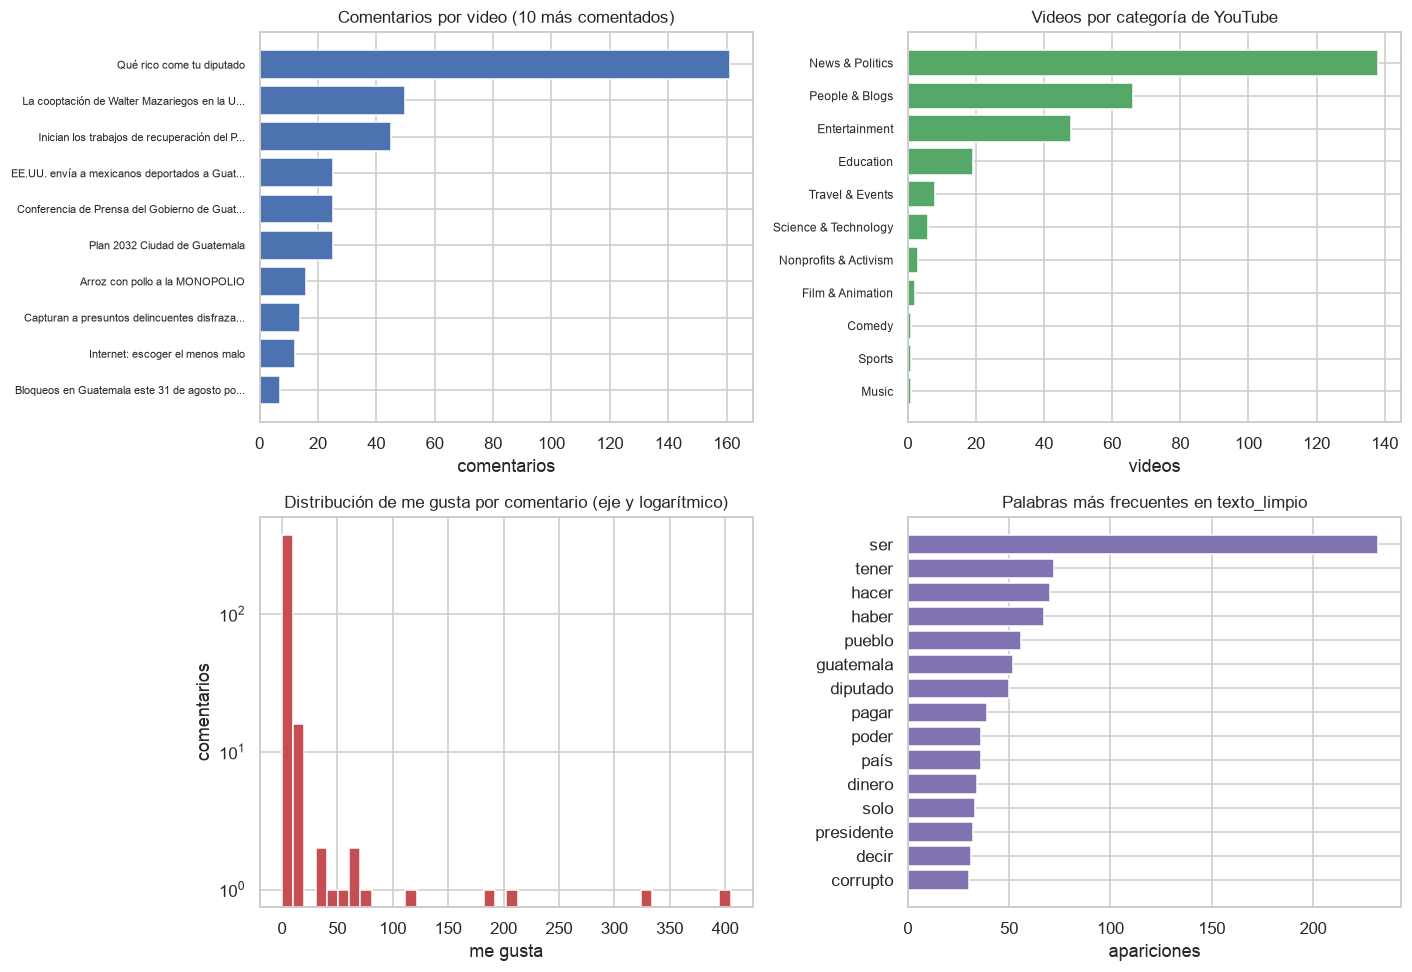

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

top_v = por_video.head(10)
etiquetas = [t[:42] + "..." if len(t) > 42 else t for t in top_v["title"]]
axes[0, 0].barh(etiquetas[::-1], top_v["comentarios"][::-1], color="#4C72B0")
axes[0, 0].set_title("Comentarios por video (10 más comentados)")
axes[0, 0].set_xlabel("comentarios")
axes[0, 0].tick_params(axis="y", labelsize=7)

cat = videos["category"].value_counts()
axes[0, 1].barh(cat.index[::-1], cat.values[::-1], color="#55A868")
axes[0, 1].set_title("Videos por categoría de YouTube")
axes[0, 1].set_xlabel("videos")
axes[0, 1].tick_params(axis="y", labelsize=8)

axes[1, 0].hist(comentarios["like_count"], bins=40, color="#C44E52")
axes[1, 0].set_yscale("log")
axes[1, 0].set_title("Distribución de me gusta por comentario (eje y logarítmico)")
axes[1, 0].set_xlabel("me gusta")
axes[1, 0].set_ylabel("comentarios")

top_p = palabras.most_common(15)[::-1]
axes[1, 1].barh([p for p, _ in top_p], [n for _, n in top_p], color="#8172B2")
axes[1, 1].set_title("Palabras más frecuentes en texto_limpio")
axes[1, 1].set_xlabel("apariciones")

plt.tight_layout()
plt.show()

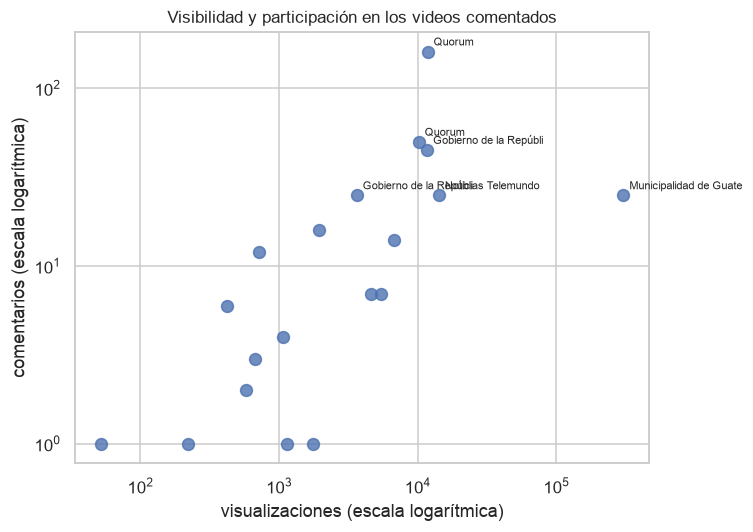

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(pop["view_count"], pop["comentarios"], s=60, color="#4C72B0", alpha=0.8)
for vid, fila in pop.iterrows():
    if fila["comentarios"] >= 25 or fila["view_count"] > 100_000:
        ax.annotate(fila["channel_name"][:22], (fila["view_count"], fila["comentarios"]),
                    fontsize=7, xytext=(4, 4), textcoords="offset points")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("visualizaciones (escala logarítmica)")
ax.set_ylabel("comentarios (escala logarítmica)")
ax.set_title("Visibilidad y participación en los videos comentados")
plt.tight_layout()
plt.show()

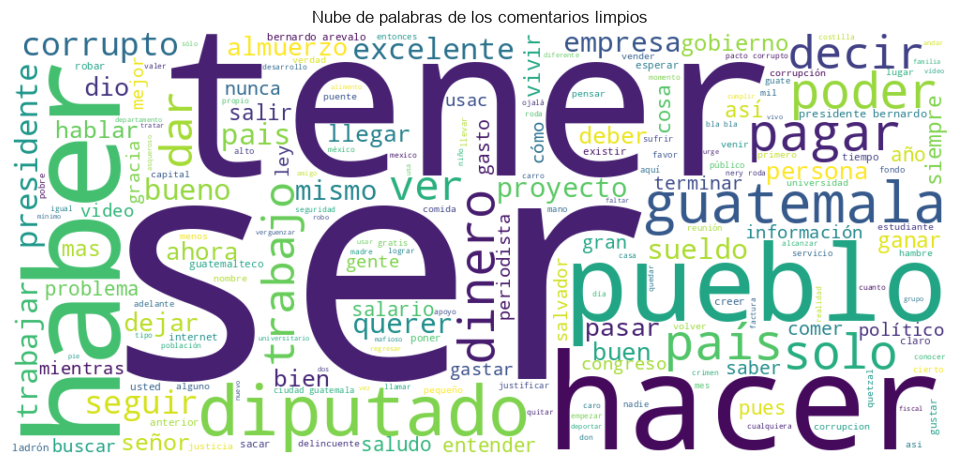

In [22]:
from wordcloud import WordCloud

texto = " ".join(comentarios["texto_limpio"].fillna("").astype(str))
nube = WordCloud(width=1000, height=450, background_color="white",
                 colormap="viridis", random_state=42).generate(texto)
plt.figure(figsize=(11, 5))
plt.imshow(nube, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras de los comentarios limpios")
plt.show()

Los gráficos ordenan el diagnóstico. La barra del video más comentado se despega del
resto, la composición por categoría muestra que el conjunto es sobre todo informativo,
los me gusta se distribuyen con una cola muy larga en la que la mayoría de comentarios
recibe cero o uno y unos pocos superan los cien, y la dispersión de vistas contra
comentarios se aleja de la diagonal. La nube de palabras acompaña al gráfico de
frecuencias, no lo sustituye, y ambos apuntan al mismo núcleo temático.

### 3.5 Preguntas obligatorias

Respondemos las seis preguntas del enunciado con la evidencia del conjunto. Primero
calculamos lo que hace falta y después interpretamos cada resultado.

In [23]:
import itertools

# audiencias compartidas y autores puente
autores_video = {vid: set(g["author_channel_id"]) for vid, g in comentarios.groupby("video_id")}
titulo = videos.set_index("video_id")["title"].to_dict()
canal_de = videos.set_index("video_id")["channel_name"].to_dict()

pares = []
for a, b in itertools.combinations(autores_video, 2):
    compartidos = autores_video[a] & autores_video[b]
    if compartidos:
        pares.append((a, b, len(compartidos)))
pares.sort(key=lambda x: -x[2])

print("pares de videos que comparten al menos un autor:", len(pares),
      f"de {len(autores_video) * (len(autores_video) - 1) // 2} pares posibles")
for a, b, n in pares:
    print(f"  {n} autor(es) | {canal_de[a]}: {titulo[a][:32]} <-> {canal_de[b]}: {titulo[b][:32]}")

pares de videos que comparten al menos un autor: 11 de 171 pares posibles
  2 autor(es) | Quorum: La cooptación de Walter Mazarieg <-> Quorum: Qué rico come tu diputado
  2 autor(es) | Quorum: Internet: escoger el menos malo <-> Quorum: Arroz con pollo a la MONOPOLIO
  1 autor(es) | Noti7: Capturan a presuntos delincuente <-> Gobierno de la República de Guatemala: Inician los trabajos de recupera
  1 autor(es) | Gobierno de la República de Guatemala: Inician los trabajos de recupera <-> Gobierno de la República de Guatemala: Conferencia de Prensa del Gobier
  1 autor(es) | Gobierno de la República de Guatemala: Conferencia de Prensa del Gobier <-> Quorum: Qué rico come tu diputado
  1 autor(es) | Quorum: Caminar en una ciudad hecha para <-> Quorum: Internet: escoger el menos malo
  1 autor(es) | Quorum: Caminar en una ciudad hecha para <-> Quorum: Arroz con pollo a la MONOPOLIO
  1 autor(es) | PrensaLibreOficial: Bloqueos en Guatemala este 31 de <-> Quorum: Qué rico come tu diputado
  

In [24]:
# autores que aparecen en más de un video
puentes = comentarios.groupby("author_channel_id").agg(
    videos_comentados=("video_id", "nunique"),
    comentarios=("comment_id", "count"),
    handle=("author_handle", "first"),
    me_gusta=("like_count", "sum"))
puentes = puentes[puentes["videos_comentados"] > 1].sort_values(
    ["videos_comentados", "comentarios"], ascending=False)
print("autores presentes en más de un video:", len(puentes),
      f"({len(puentes) / comentarios['author_channel_id'].nunique():.1%} de los autores)")
puentes

autores presentes en más de un video: 9 (2.7% de los autores)


,videos_comentados,comentarios,handle,me_gusta
author_channel_id,,,,
UCvcu1kR8xMYy_I1Ty-2mV2Q,3,4,/@hashojea7348,0
UCpsKOkt5iWTbenzeuq7dsmQ,3,3,/@inge_vergueta,4
UCHTGCgY2l-DQJIvlA_cpa_Q,2,3,/@virgiliogarcia3039,14
UCylqlpsh8ENNM1LqgQ1KbxA,2,3,/@Jel.Awesh.M,1
UCbrtvygfRT6QXqWDNrOf-cA,2,2,/@Alejandro00710,0
UCdFlugHJJa4l3YqWuNRmvXw,2,2,/@MarcosCarillo-b1r,0
UCjZgFEowMBrsjodqfovzdKw,2,2,/@franciscoflores3120,0
UCsUCN0Yq_UyTvKjOJLmNrnQ,2,2,/@moisesvaldez4043,0
UCzZ6dDCEsLMXbc5pCFXIprw,2,2,/@josegil3813,0


In [25]:
# temas por video y un indicador léxico preliminar de tono
NEG = ["corrupto", "corrupción", "ladrón", "robar", "mentira", "vergüenza",
       "inepto", "mafioso", "peor", "malo"]
POS = ["excelente", "felicidades", "bueno", "buen", "gracias", "bendición",
       "mejor", "éxito", "genial"]

def cuenta_lexico(serie, lexico):
    s = serie.fillna("").astype(str)
    return int(sum(s.str.count(rf"\b{w}\b").sum() for w in lexico))

print("temas por video (palabras más frecuentes en los 4 videos más comentados):")
vacias = {"ser", "tener", "hacer", "haber", "poder", "decir", "dar", "ver", "solo", "así"}
for vid in por_video.head(4).index:
    sub = comentarios[comentarios["video_id"] == vid]
    cont = Counter()
    for t in sub["texto_limpio"].fillna(""):
        cont.update(t.split())
    for w in vacias:
        cont.pop(w, None)
    neg, pos_ = cuenta_lexico(sub["texto_limpio"], NEG), cuenta_lexico(sub["texto_limpio"], POS)
    print(f"\n  {canal_de[vid]} | {titulo[vid][:45]} ({len(sub)} comentarios)")
    print("   temas:", ", ".join(w for w, _ in cont.most_common(10)))
    print(f"   indicador léxico: {neg} términos críticos, {pos_} términos de aprobación")

print("\nen el conjunto completo:", cuenta_lexico(comentarios["texto_limpio"], NEG),
      "términos críticos y", cuenta_lexico(comentarios["texto_limpio"], POS),
      "de aprobación")

temas por video (palabras más frecuentes en los 4 videos más comentados):

  Quorum | Qué rico come tu diputado (161 comentarios)
   temas: pueblo, diputado, pagar, dinero, trabajo, sueldo, almuerzo, trabajar, corrupto, ganar
   indicador léxico: 34 términos críticos, 18 términos de aprobación

  Quorum | La cooptación de Walter Mazariegos en la USAC (50 comentarios)
   temas: corrupto, usac, estudiante, universidad, buen, excelente, información, universitario, seguir, pueblo
   indicador léxico: 16 términos críticos, 14 términos de aprobación

  Gobierno de la República de Guatemala | Inician los trabajos de recuperación del Puen (45 comentarios)
   temas: presidente, año, guatemala, proyecto, terminar, bernardo, arevalo, puente, vivir, pais
   indicador léxico: 9 términos críticos, 7 términos de aprobación

  Noticias Telemundo | EE.UU. envía a mexicanos deportados a Guatema (25 comentarios)
   temas: you, país, deportar, entrar, pais, usa, bueno, persona, pasar, mexicano
   indicado

**¿Qué videos y canales concentran la mayor participación observada?** La participación
se concentra en el canal Quorum, que reúne el 63.1 % de los comentarios, y dentro de él
en el video *Qué rico come tu diputado*, con 161 comentarios, casi el 40 % del total. Los
tres videos más comentados suman el 63.1 % y los cinco primeros el 75.4 %. Del lado
institucional, el canal del Gobierno de la República aporta 70 comentarios repartidos en
dos videos.

**¿Existen audiencias compartidas entre videos, canales o temas?** Sí, pero son mínimas.
De los 171 pares posibles entre los 19 videos comentados, solo 11 comparten al menos un
autor, y en el par más fuerte se comparten apenas dos autores. La mayoría de esos pares
son videos del mismo canal, Quorum, lo que sugiere que la audiencia compartida se explica
sobre todo por seguir a un canal y no por seguir un tema a través de canales distintos.
Aun así hay cruces entre canales, por ejemplo entre Prensa Libre y Quorum, o entre Noti7
y el Gobierno de la República.

**¿Qué autores funcionan como puentes?** Solo 9 de los 332 autores, el 2.7 %, comentaron
en más de un video. Los dos más conectados, hashojea7348 e inge_vergueta, aparecen en tres
videos cada uno y son los únicos que enlazan tres contenidos distintos. Estos autores son
los que sostienen la conexión entre videos que de otra forma quedarían separados, y por eso
son determinantes en la red del ejercicio 4.

**¿Qué temas y sentimientos caracterizan a las principales comunidades?** Cada video reúne
un vocabulario propio. En el video más comentado dominan pueblo, diputado, pagar, dinero,
sueldo y almuerzo, es decir la crítica al gasto de los diputados. En el de la USAC dominan
corrupto, usac, estudiante, universidad y pacto. En el del puente de gobierno dominan
presidente, proyecto, puente y el nombre del presidente. El indicador léxico preliminar
muestra que el tono cambia según el contenido, el video de los diputados acumula más
términos críticos que de aprobación, mientras que el de la USAC y el del puente están
equilibrados. Es solo una aproximación por conteo de palabras, el análisis formal de
sentimiento se hace en el ejercicio 9 del documento final.

**¿La visibilidad coincide con la participación?** Solo parcialmente. La correlación de
Spearman entre visualizaciones y comentarios es 0.811, así que en el orden general sí se
corresponden, pero la correlación cruda es 0.067 porque el video más visto, con 304 089
vistas, recibe 25 comentarios y otro con 11 775 vistas recibe 161. La tasa de comentarios
por mil visualizaciones de los videos de Quorum es varias veces mayor que la del resto,
de modo que la visibilidad y la disposición a participar no son la misma cosa.

**¿Qué conclusiones están limitadas por la recolección?** Prácticamente todas las que
comparan canales o temas. Los comentarios cubren 19 de 293 videos y 8 de 97 canales, y
provienen de una recolección guiada por consultas de búsqueda, así que la ausencia de
comentarios en un canal no significa que no los tenga. Las fechas son relativas, los
conteos se observaron en un solo momento y solo se recolectaron comentarios principales,
sin el texto ni el autor de las respuestas. Todo lo anterior describe la muestra observada,
no la actividad real de los canales ni el comportamiento de los usuarios de YouTube.

### 3.6 Preguntas adicionales

Del análisis surgen tres preguntas propias que respondemos con los mismos datos.

**Pregunta 1. ¿Los comentarios que reciben más me gusta son también los que generan más
respuestas?** Interesa porque los me gusta y las respuestas son dos formas distintas de
reacción y conviene saber si miden lo mismo.

In [26]:
print("correlación me gusta vs respuestas | Pearson:",
      round(comentarios["like_count"].corr(comentarios["reply_count"]), 3),
      "| Spearman:",
      round(comentarios["like_count"].corr(comentarios["reply_count"], method="spearman"), 3))
print()
print(comentarios.groupby(comentarios["reply_count"] > 0)["like_count"].agg(
    comentarios="count", promedio="mean", mediana="median").round(2).rename(
    index={False: "sin respuestas", True: "con al menos una respuesta"}).to_string())
print("\ncomentarios con más me gusta:")
print(comentarios.nlargest(5, "like_count")[
    ["author_handle", "like_count", "reply_count", "video_id"]].to_string(index=False))

correlación me gusta vs respuestas | Pearson: 0.537 | Spearman: 0.251

                            comentarios  promedio  mediana
reply_count                                               
sin respuestas                      376      2.53      1.0
con al menos una respuesta           30     45.83      2.5

comentarios con más me gusta:
           author_handle  like_count  reply_count    video_id
                 /@zetag         405            3 lj983NWyAQY
       /@elenaluarca9377         329            5 lj983NWyAQY
      /@samuelaguilar529         211            3 lj983NWyAQY
            /@TheAlexX_C         191            2 lj983NWyAQY
/@sabinamarinaguerra3248         113            1 lj983NWyAQY


La respuesta es que se relacionan pero no coinciden. La correlación de Pearson es 0.537 y
la de Spearman apenas 0.251, lo que indica que la asociación la producen unos pocos
comentarios muy destacados y no una tendencia general. Los 30 comentarios que recibieron
respuestas tienen un promedio de 45.8 me gusta frente a 2.5 de los demás, pero su mediana
es 2.5 contra 1, es decir que la diferencia está en la cola y no en el comentario típico.
Aprobar un comentario cuesta un clic y responderlo cuesta escribir, así que el me gusta
mide una adhesión mucho más barata que la respuesta.

**Pregunta 2. ¿Reciben participación observada los videos de canales oficiales de
gobierno?** El conjunto fue recolectado en buena parte con consultas de canales oficiales,
así que vale la pena verificar si esa parte del corpus aparece en los comentarios.

In [27]:
videos["comentado"] = videos["video_id"].isin(set(comentarios["video_id"]))
tabla = pd.crosstab(videos["source_group"], videos["comentado"])
tabla.columns = ["sin comentarios", "con comentarios"]
print(tabla.to_string())
print("\ncanales con comentarios observados:", comentarios["channel_id"].nunique(),
      "de", videos["channel_id"].nunique())
print("\nvisualizaciones según si el video tiene comentarios recolectados:")
print(videos.groupby("comentado")["view_count"].agg(
    videos="count", mediana="median", promedio="mean", maximo="max").round(1).to_string())

              sin comentarios  con comentarios
source_group                                  
channel                     4                7
official_gov              105                0
topic                     165               12

canales con comentarios observados: 8 de 97

visualizaciones según si el video tiene comentarios recolectados:
           videos  mediana  promedio   maximo
comentado                                    
False         274   1149.5   63230.4  8190449
True           19   1954.0   20046.1   304089


Ninguno de los 105 videos clasificados como official_gov tiene comentarios en el conjunto,
toda la participación observada proviene de los grupos topic y channel. Esto no permite
concluir que los canales oficiales no reciban comentarios, es un rasgo del procedimiento
de recolección, es posible que para esas consultas solo se hayan descargado los metadatos
del video y no sus comentarios, o que los comentarios estuvieran deshabilitados. La
consecuencia práctica es que cualquier comparación entre gobierno y medios en este
conjunto quedaría sesgada, y por eso el análisis de participación se limita a los 19
videos efectivamente comentados. Nótese además que los videos con comentarios no son los
más vistos, su mediana de visualizaciones es mayor que la del resto pero el video más
visto del conjunto, con más de ocho millones de vistas, no aporta ningún comentario.

**Pregunta 3. ¿Los autores recurrentes se comportan distinto de los que comentan una sola
vez?** Si los autores que vuelven escribieran más o recibieran más aprobación, tendría
sentido tratarlos como un grupo aparte en el análisis de la red.

In [28]:
frecuencia = comentarios["author_channel_id"].map(
    comentarios["author_channel_id"].value_counts())
comentarios["recurrente"] = frecuencia > 1
comentarios["n_palabras"] = comentarios["texto_original"].str.split().str.len()

print(comentarios.groupby("recurrente").agg(
    comentarios=("comment_id", "count"),
    autores=("author_channel_id", "nunique"),
    palabras_promedio=("n_palabras", "mean"),
    me_gusta_promedio=("like_count", "mean"),
    me_gusta_mediana=("like_count", "median")).round(2).rename(
    index={False: "autor de un solo comentario", True: "autor recurrente"}).to_string())

                             comentarios  autores  palabras_promedio  me_gusta_promedio  me_gusta_mediana
recurrente                                                                                               
autor de un solo comentario          286      286              25.72               7.47               1.0
autor recurrente                     120       46              20.12               1.58               1.0


Los 46 autores recurrentes producen 120 comentarios, casi el 30 % del total, aunque son el
14 % de los autores. Sus comentarios son algo más cortos, 20.1 palabras frente a 25.7, y
reciben bastante menos aprobación en promedio, 1.58 me gusta frente a 7.47, con la misma
mediana de 1. Es decir, la recurrencia aporta volumen pero no visibilidad, los comentarios
que se vuelven populares suelen venir de autores que aparecen una sola vez. Para la red
esto significa que los autores con más grado no son necesariamente los más influyentes en
términos de reacción del público.

## Ejercicio 4. Construcción de la red bipartita autor-video

Construimos una red no dirigida con dos tipos de nodos, los autores de comentarios,
identificados por author_channel_id, y los videos, identificados por video_id. No se
crean aristas entre autores ni entre videos, toda relación pasa de un autor a un video.
Usamos los identificadores y no los nombres visibles, porque un mismo nombre puede
repetirse o cambiar con el tiempo.

### 4.1 y 4.2 Nodos, aristas y pesos

Existe una arista entre un autor y un video cuando ese autor publicó al menos un
comentario en ese video, y el peso de la arista es el número de comentarios que ese
autor publicó en ese video. Como los comentarios son la unidad observada, agrupamos
por la pareja autor-video y contamos.

In [29]:
import networkx as nx

aristas = comentarios.groupby(["author_channel_id", "video_id"]).agg(
    peso=("comment_id", "count"),
    me_gusta=("like_count", "sum"),
    respuestas=("reply_count", "sum")).reset_index()

autores_ids = aristas["author_channel_id"].unique()
videos_ids = aristas["video_id"].unique()

B = nx.Graph()
B.add_nodes_from(autores_ids, tipo="autor", bipartite=0)
B.add_nodes_from(videos_ids, tipo="video", bipartite=1)
for fila in aristas.itertuples(index=False):
    B.add_edge(fila.author_channel_id, fila.video_id, peso=fila.peso,
               me_gusta=fila.me_gusta, respuestas=fila.respuestas)

print("¿la red es bipartita?", nx.is_bipartite(B))
print("nodos:", B.number_of_nodes(), f"({len(autores_ids)} autores y {len(videos_ids)} videos)")
print("aristas:", B.number_of_edges())
print("suma de los pesos:", int(aristas["peso"].sum()),
      "= comentarios del conjunto:", len(comentarios))
print("aristas con peso mayor que 1:", int((aristas["peso"] > 1).sum()),
      "| peso máximo:", int(aristas["peso"].max()))

¿la red es bipartita? True
nodos: 351 (332 autores y 19 videos)
aristas: 343
suma de los pesos: 406 = comentarios del conjunto: 406
aristas con peso mayor que 1: 40 | peso máximo: 6


La suma de los pesos coincide con los 406 comentarios, lo que confirma que ningún
comentario quedó fuera y que ninguno se contó dos veces. La mayoría de las aristas tiene
peso uno, es decir un autor que comentó una sola vez en un video, y 40 aristas tienen
peso mayor porque el autor comentó varias veces en el mismo contenido.

### 4.3 Tabla de nodos y tabla de aristas

Entregamos las dos tablas con el tipo de nodo y los atributos relevantes de cada uno.
Los autores llevan su handle, su número de comentarios, de videos y de me gusta; los
videos llevan su título, canal, categoría, visualizaciones y el número de autores que
participaron. Las dos tablas se guardan en salidas/ para poder reutilizarlas.

In [30]:
info_autor = comentarios.groupby("author_channel_id").agg(
    etiqueta=("author_handle", "first"),
    comentarios=("comment_id", "count"),
    videos=("video_id", "nunique"),
    me_gusta=("like_count", "sum"),
    respuestas=("reply_count", "sum")).reset_index().rename(
    columns={"author_channel_id": "id"})
info_autor["tipo"] = "autor"

info_video = comentarios.groupby("video_id").agg(
    comentarios=("comment_id", "count"),
    autores=("author_channel_id", "nunique"),
    me_gusta=("like_count", "sum"),
    respuestas=("reply_count", "sum")).reset_index()
info_video = info_video.merge(
    videos[["video_id", "title", "channel_id", "channel_name", "category",
            "view_count", "source_group"]], on="video_id", how="left")
info_video = info_video.rename(columns={"video_id": "id", "title": "etiqueta"})
info_video["tipo"] = "video"

tabla_nodos = pd.concat([info_autor, info_video], ignore_index=True)
tabla_nodos["grado"] = tabla_nodos["id"].map(dict(B.degree()))
tabla_nodos["fuerza"] = tabla_nodos["id"].map(
    dict(B.degree(weight="peso")))
tabla_nodos = tabla_nodos[["id", "tipo", "etiqueta", "grado", "fuerza", "comentarios",
                           "autores", "videos", "me_gusta", "respuestas", "channel_id",
                           "channel_name", "category", "view_count", "source_group"]]

print("tabla de nodos:", tabla_nodos.shape)
print(tabla_nodos["tipo"].value_counts().to_string())
tabla_nodos[tabla_nodos["tipo"] == "video"].sort_values("grado", ascending=False).head(5)

tabla de nodos: (351, 15)
tipo
autor    332
video     19


,id,tipo,etiqueta,grado,fuerza,comentarios,autores,videos,me_gusta,respuestas,channel_id,channel_name,category,view_count,source_group
346,n8iP75gIpmw,video,Qué rico come tu diputado,128,161,161,128.0,NaN,358,3,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum,News & Politics,11775.0,topic
344,j43HgwYFKfk,video,La cooptación de Walter Mazariegos en la USAC,49,50,50,49.0,NaN,91,0,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum,News & Politics,10156.0,topic
334,6W4u8sGEnGM,video,Inician los trabajos de recuperación del Puent...,32,45,45,32.0,NaN,90,11,UC-ZtFBHzgkYFh7whZkuR_Ag,Gobierno de la República de Guatemala,Entertainment,11670.0,topic
345,lj983NWyAQY,video,Plan 2032 Ciudad de Guatemala,25,25,25,25.0,NaN,1697,16,UCXa6LVjBzUtmcM3cwbd9e2w,Municipalidad de Guatemala,News & Politics,304089.0,topic
337,PjmxCj-a9Hg,video,Conferencia de Prensa del Gobierno de Guatemal...,19,25,25,19.0,NaN,20,4,UC-ZtFBHzgkYFh7whZkuR_Ag,Gobierno de la República de Guatemala,Entertainment,3628.0,topic


In [31]:
tabla_aristas = aristas.rename(columns={"author_channel_id": "origen", "video_id": "destino"})
tabla_aristas["tipo_arista"] = "autor-video"
tabla_aristas = tabla_aristas[["origen", "destino", "peso", "tipo_arista",
                               "me_gusta", "respuestas"]]

print("tabla de aristas:", tabla_aristas.shape)
print("distribución de pesos:")
print(tabla_aristas["peso"].value_counts().sort_index().to_string())

tabla_nodos.to_csv(SALIDAS / "red_nodos.csv", index=False)
tabla_aristas.to_csv(SALIDAS / "red_aristas.csv", index=False)
print("\nguardadas en salidas/: red_nodos.csv, red_aristas.csv")
tabla_aristas.sort_values("peso", ascending=False).head(5)

tabla de aristas: (343, 6)
distribución de pesos:
peso
1    303
2     28
3      7
4      1
5      2
6      2

guardadas en salidas/: red_nodos.csv, red_aristas.csv


,origen,destino,peso,tipo_arista,me_gusta,respuestas
244,UCi2KiZq63sRq8Mfbcp-MelQ,OkXlHx0hx-8,6,autor-video,1,0
331,UCyJhqmMbsvjpoarBBStA2kg,6W4u8sGEnGM,6,autor-video,14,0
165,UCV3fr-YOixFKCZBbJP1-X4w,6W4u8sGEnGM,5,autor-video,17,0
33,UC5H8ASmMC9WrURmzeB4ySog,n8iP75gIpmw,5,autor-video,6,0
57,UC9vMq1YF-e7C-VO0SHkbUTA,n8iP75gIpmw,4,autor-video,0,0


### 4.4 Visualización de la red completa

Dibujamos la red completa, con los 351 nodos y las 343 aristas, sin quitar componentes
pequeñas ni nodos de grado bajo, porque justamente la fragmentación es uno de los
resultados. Los videos se dibujan como cuadrados y con tamaño proporcional al número de
autores que participaron, los autores como círculos pequeños, y el grosor de la arista
representa su peso.

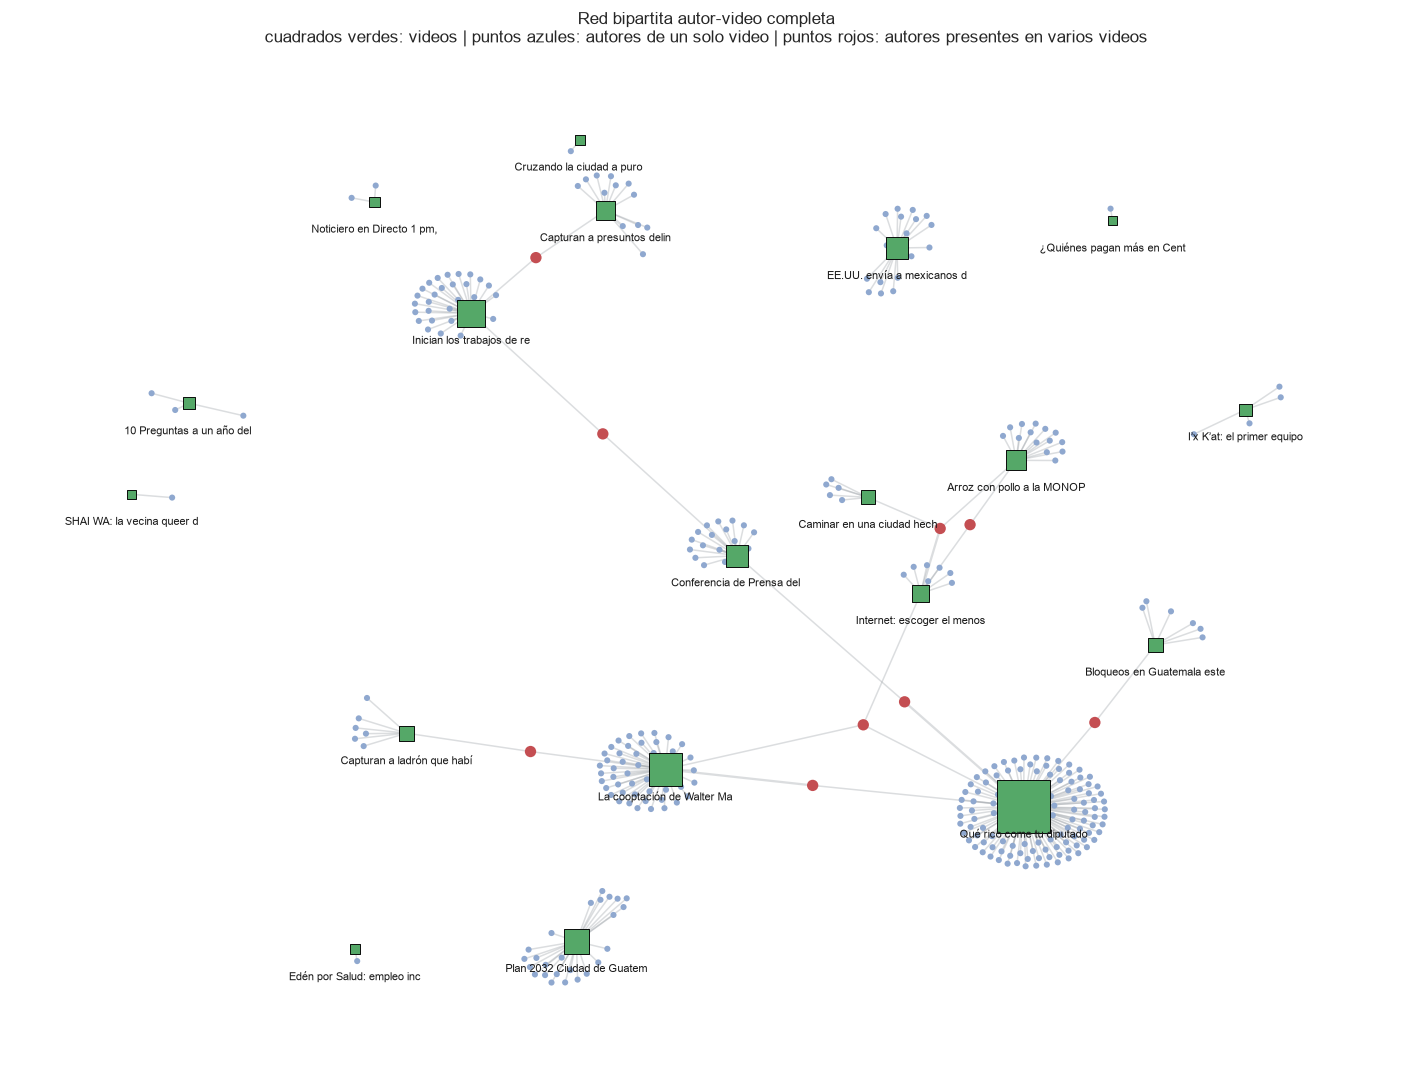

In [32]:
posiciones = nx.spring_layout(B, k=0.32, iterations=250, seed=7, weight="peso")

nodos_video = [n for n, d in B.nodes(data=True) if d["tipo"] == "video"]
nodos_autor = [n for n, d in B.nodes(data=True) if d["tipo"] == "autor"]
grado_autor = dict(B.degree(nodos_autor))
tam_video = [30 + 9 * B.degree(n) for n in nodos_video]
color_autor = ["#C44E52" if grado_autor[n] > 1 else "#8FA8CF" for n in nodos_autor]
tam_autor = [55 if grado_autor[n] > 1 else 16 for n in nodos_autor]

fig, ax = plt.subplots(figsize=(13, 10))
nx.draw_networkx_edges(B, posiciones, ax=ax, alpha=0.35, edge_color="#9aa0a6",
                       width=[0.5 + 0.5 * d["peso"] for _, _, d in B.edges(data=True)])
nx.draw_networkx_nodes(B, posiciones, nodelist=nodos_autor, node_size=tam_autor,
                       node_color=color_autor, linewidths=0, ax=ax)
nx.draw_networkx_nodes(B, posiciones, nodelist=nodos_video, node_size=tam_video,
                       node_color="#55A868", node_shape="s", edgecolors="black",
                       linewidths=0.6, ax=ax)
etiquetas_video = {n: titulo[n][:26] for n in nodos_video}
pos_etiquetas = {n: (x, y - 0.055) for n, (x, y) in posiciones.items()}
nx.draw_networkx_labels(B, pos_etiquetas, labels=etiquetas_video, font_size=7,
                        font_color="#1a1a1a", ax=ax)
ax.set_title("Red bipartita autor-video completa\n"
             "cuadrados verdes: videos | puntos azules: autores de un solo video | "
             "puntos rojos: autores presentes en varios videos")
ax.axis("off")
plt.tight_layout()
plt.show()

In [33]:
# lectura estructural mínima de la figura
componentes = sorted(nx.connected_components(B), key=len, reverse=True)
print("componentes conexas:", len(componentes))
print("tamaños:", [len(c) for c in componentes])
mayor = componentes[0]
print("componente más grande:", len(mayor), "nodos",
      f"({len(mayor) / B.number_of_nodes():.1%} de la red),",
      sum(1 for n in mayor if B.nodes[n]["tipo"] == "video"), "videos y",
      sum(1 for n in mayor if B.nodes[n]["tipo"] == "autor"), "autores")
print("grado medio:", round(2 * B.number_of_edges() / B.number_of_nodes(), 2))
print("densidad bipartita:",
      round(B.number_of_edges() / (len(autores_ids) * len(videos_ids)), 4))
print("autores con grado 1:", sum(1 for n in nodos_autor if B.degree(n) == 1),
      "| autores con grado mayor que 1:", sum(1 for n in nodos_autor if B.degree(n) > 1))
print("\ngrado de los videos:")
print(tabla_nodos[tabla_nodos["tipo"] == "video"].set_index("etiqueta")["grado"]
      .sort_values(ascending=False).to_string())

componentes conexas: 10
tamaños: [286, 26, 19, 5, 4, 3, 2, 2, 2, 2]
componente más grande: 286 nodos (81.5% de la red), 10 videos y 276 autores
grado medio: 1.95
densidad bipartita: 0.0544
autores con grado 1: 323 | autores con grado mayor que 1: 9

grado de los videos:
etiqueta
Qué rico come tu diputado                                                                            128
La cooptación de Walter Mazariegos en la USAC                                                         49
Inician los trabajos de recuperación del Puente Belice II.                                            32
Plan 2032 Ciudad de Guatemala                                                                         25
Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt                                           19
EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México | Noticias Telemundo     18
Arroz con pollo a la MONOPOLIO                                                            

La figura muestra una red en forma de estrellas. Cada video aparece como el centro de un
abanico de autores que solo comentaron ahí, y los pocos puntos rojos son los nueve autores
que enlazan más de un video. La red se separa en 10 componentes, y aunque la mayor reúne
286 nodos, esa componente se sostiene por muy pocas aristas puente, de modo que la
conexión es real pero frágil. Las cuatro componentes de dos nodos corresponden a videos
con un único comentario, que quedan completamente aislados del resto. Este aislamiento es
observado, no necesariamente real, porque el conjunto solo recolectó una parte de los
comentarios de cada video.

### 4.5 Qué significa una arista

Una arista entre un autor y un video significa exactamente una cosa, que en el momento de
la recolección ese autor tenía al menos un comentario principal publicado en ese video, y
su peso indica cuántos. Nada más. No implica que el autor haya visto el video completo,
que esté de acuerdo con su contenido, ni que apruebe al canal, un comentario crítico
produce exactamente la misma arista que uno elogioso. Tampoco implica relación alguna
entre dos autores conectados al mismo video, no hay amistad, ni conversación, ni
interacción directa entre ellos, solo coincidencia en el mismo espacio de comentarios.
Los datos no permiten saber quién respondió a quién, la variable reply_count solo dice
cuántas respuestas recibió un comentario, y por eso no se usa como arista entre usuarios.
La co-participación que se ve en la red es, en sentido estricto, atención compartida hacia
un mismo contenido.

## Cierre del avance

Con esto quedan cubiertos los cuatro ejercicios del avance. Los datos se cargaron e
integraron por video_id con los 406 comentarios asociados a un video del conjunto, se
diagnosticó su calidad, se normalizaron los identificadores, se convirtieron los conteos
y se generaron las dos versiones del texto. El análisis exploratorio mostró una
participación muy concentrada en pocos videos y canales pero muy repartida entre autores,
una relación solo parcial entre visibilidad y participación, y una cobertura limitada a 19
de los 293 videos. Sobre esa base se construyó la red bipartita autor-video de 351 nodos y
343 aristas, con sus tablas de nodos y aristas, cuya estructura de estrellas apenas
conectadas es el punto de partida para las proyecciones, las comunidades y la centralidad
del documento final.

## Ejercicio 5. Proyecciones de la red

La red bipartita se puede proyectar sobre cualquiera de sus dos conjuntos de nodos. Al
proyectar sobre los autores obtenemos una red de personas que coincidieron en un mismo
video, y al proyectar sobre los videos obtenemos una red de contenidos que comparten
público. Ninguna de las dos agrega información nueva, las dos son lecturas distintas de
las mismas 343 aristas autor-video, así que conviene interpretarlas con el mismo cuidado
que la red original.

### 5.1 Proyección autor-autor

Dos autores se conectan si comentaron en el mismo video, y el peso de la arista es el
número de videos que comparten. Usamos la proyección ponderada de networkx, que cuenta
exactamente los vecinos comunes de cada par en la red bipartita.

In [34]:
from networkx.algorithms import bipartite as bip

P_autores = bip.weighted_projected_graph(B, autores_ids)

print("proyección autor-autor")
print("  nodos:", P_autores.number_of_nodes(), "| aristas:", P_autores.number_of_edges())
print("  densidad:", round(nx.density(P_autores), 4))
print("  grado medio:", round(2 * P_autores.number_of_edges() / P_autores.number_of_nodes(), 2))

pesos_aa = pd.Series([d["weight"] for _, _, d in P_autores.edges(data=True)])
print("  pesos: máximo", int(pesos_aa.max()), "| aristas con peso mayor que 1:",
      int((pesos_aa > 1).sum()))

etiqueta_autor = comentarios.drop_duplicates("author_channel_id").set_index(
    "author_channel_id")["author_handle"].to_dict()
print("\n  pares de autores que comparten más de un video:")
for a, b, d in P_autores.edges(data=True):
    if d["weight"] > 1:
        print(f"    {etiqueta_autor[a]} <-> {etiqueta_autor[b]}: {d['weight']} videos")

proyección autor-autor
  nodos: 332 | aristas: 10732
  densidad: 0.1953
  grado medio: 64.65
  pesos: máximo 2 | aristas con peso mayor que 1: 2

  pares de autores que comparten más de un video:
    /@Alejandro00710 <-> /@hashojea7348: 2 videos
    /@inge_vergueta <-> /@Jel.Awesh.M: 2 videos


La proyección autor-autor es densa y engañosa si se lee sin cuidado. Tiene 10 732 aristas
producidas por solo 343 aristas originales, porque cada video convierte a todos sus
comentaristas en un grupo completamente conectado. El video más comentado, con 128
autores, aporta por sí solo 8 128 aristas. Además casi todas tienen peso uno, solo dos
pares de autores coincidieron en más de un video, así que la enorme mayoría de esas
conexiones significa nada más haber comentado el mismo contenido una vez.

### 5.2 Proyección video-video

Dos videos se conectan si comparten al menos un autor, y el peso es el número de autores
compartidos.

In [35]:
P_videos = bip.weighted_projected_graph(B, videos_ids)

print("proyección video-video")
print("  nodos:", P_videos.number_of_nodes(), "| aristas:", P_videos.number_of_edges())
print("  densidad:", round(nx.density(P_videos), 4))
print("  grado medio:", round(2 * P_videos.number_of_edges() / P_videos.number_of_nodes(), 2))
print("  videos sin ningún autor compartido:", len(list(nx.isolates(P_videos))))

print("\n  aristas de la proyección video-video:")
for a, b, d in sorted(P_videos.edges(data=True), key=lambda e: -e[2]["weight"]):
    print(f"    {d['weight']} autor(es) | {canal_de[a]}: {titulo[a][:30]} <-> "
          f"{canal_de[b]}: {titulo[b][:30]}")

proyección video-video
  nodos: 19 | aristas: 11
  densidad: 0.0643
  grado medio: 1.16
  videos sin ningún autor compartido: 9

  aristas de la proyección video-video:
    2 autor(es) | Quorum: La cooptación de Walter Mazari <-> Quorum: Qué rico come tu diputado
    2 autor(es) | Quorum: Internet: escoger el menos mal <-> Quorum: Arroz con pollo a la MONOPOLIO
    1 autor(es) | Gobierno de la República de Guatemala: Inician los trabajos de recupe <-> Noti7: Capturan a presuntos delincuen
    1 autor(es) | Gobierno de la República de Guatemala: Inician los trabajos de recupe <-> Gobierno de la República de Guatemala: Conferencia de Prensa del Gobi
    1 autor(es) | Quorum: La cooptación de Walter Mazari <-> TN23 Guatemala: Capturan a ladrón que había qu
    1 autor(es) | Quorum: La cooptación de Walter Mazari <-> Quorum: Internet: escoger el menos mal
    1 autor(es) | Quorum: Qué rico come tu diputado <-> PrensaLibreOficial: Bloqueos en Guatemala este 31 
    1 autor(es) | Quorum: Qué

La proyección video-video es la imagen contraria, apenas 11 aristas entre 19 videos y 9
videos completamente aislados. El peso máximo es dos, es decir que ni siquiera los pares
de contenidos más relacionados comparten más de dos comentaristas.

### 5.3 Comparación de las dos proyecciones

Las dos proyecciones responden preguntas distintas y por eso tienen tamaños tan
diferentes.

In [36]:
comparacion = pd.DataFrame({
    "autor-autor": {
        "nodos": P_autores.number_of_nodes(),
        "aristas": P_autores.number_of_edges(),
        "densidad": round(nx.density(P_autores), 4),
        "grado medio": round(2 * P_autores.number_of_edges() / P_autores.number_of_nodes(), 2),
        "peso máximo": int(pesos_aa.max()),
        "aristas de peso 1 (%)": round(100 * (pesos_aa == 1).mean(), 2),
        "componentes": nx.number_connected_components(P_autores),
        "nodos aislados": len(list(nx.isolates(P_autores)))},
    "video-video": {
        "nodos": P_videos.number_of_nodes(),
        "aristas": P_videos.number_of_edges(),
        "densidad": round(nx.density(P_videos), 4),
        "grado medio": round(2 * P_videos.number_of_edges() / P_videos.number_of_nodes(), 2),
        "peso máximo": int(max(d["weight"] for _, _, d in P_videos.edges(data=True))),
        "aristas de peso 1 (%)": round(100 * np.mean(
            [d["weight"] == 1 for _, _, d in P_videos.edges(data=True)]), 2),
        "componentes": nx.number_connected_components(P_videos),
        "nodos aislados": len(list(nx.isolates(P_videos)))}})
comparacion

,autor-autor,video-video
nodos,332.0000,19.0000
aristas,10732.0000,11.0000
densidad,0.1953,0.0643
grado medio,64.6500,1.1600
peso máximo,2.0000,2.0000
aristas de peso 1 (%),99.9800,81.8200
componentes,10.0000,10.0000
nodos aislados,4.0000,9.0000


La proyección autor-autor representa coasistencia, personas que estuvieron en la misma
sección de comentarios. No representa conversación ni conocimiento mutuo, y su altísima
densidad, 0.195, es un artefacto de la proyección, no un hallazgo sobre la audiencia,
porque un solo video muy comentado basta para generar miles de aristas. Su lectura útil
es la de identificar públicos que se solapan, es decir los pocos pares de autores que
coincidieron en más de un contenido.

La proyección video-video representa audiencia compartida entre contenidos, y es la que
aporta información sustantiva. Cada arista significa que hubo personas que comentaron en
los dos videos, y por eso sus 11 aristas son informativas mientras que las 10 732 de la
otra proyección son en su mayoría redundantes. Que 9 de 19 videos queden aislados indica
que el consumo observado es local a cada video, con muy poco tránsito de público entre
contenidos, y que los pocos cruces que existen se concentran dentro del mismo canal.

### 5.4 Visualización de las proyecciones

Dibujamos las dos proyecciones. En la de autores, para que la figura sea legible pese a
las más de diez mil aristas, mantenemos todos los nodos y todas las aristas, pero
dibujamos las aristas muy tenues y coloreamos cada autor según el video en el que
comentó, de modo que se vea que los grupos densos corresponden a videos.

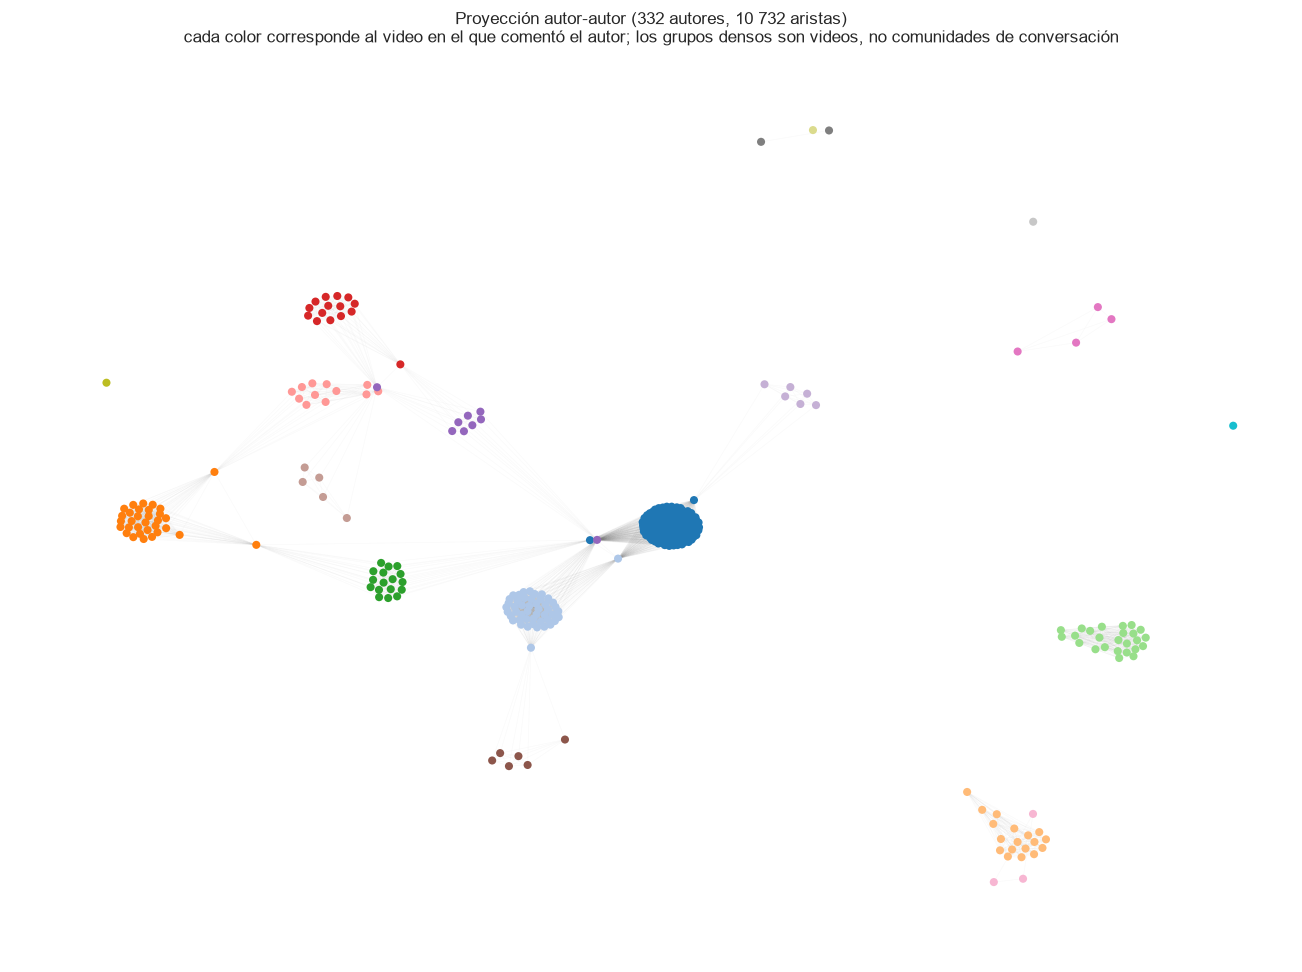

In [37]:
video_principal = comentarios.groupby("author_channel_id")["video_id"].agg(
    lambda s: s.value_counts().idxmax())
orden_videos = list(por_video.index)
paleta = dict(zip(orden_videos, sns.color_palette("tab20", len(orden_videos))))
colores_aa = [paleta[video_principal[n]] for n in P_autores.nodes()]

pos_aa = nx.spring_layout(P_autores, k=0.25, iterations=80, seed=11)

fig, ax = plt.subplots(figsize=(12, 9))
nx.draw_networkx_edges(P_autores, pos_aa, ax=ax, alpha=0.04,
                       edge_color="#7f7f7f", width=0.4)
nx.draw_networkx_nodes(P_autores, pos_aa, ax=ax, node_size=28,
                       node_color=colores_aa, linewidths=0)
ax.set_title("Proyección autor-autor (332 autores, 10 732 aristas)\n"
             "cada color corresponde al video en el que comentó el autor; "
             "los grupos densos son videos, no comunidades de conversación")
ax.axis("off")
plt.tight_layout()
plt.show()

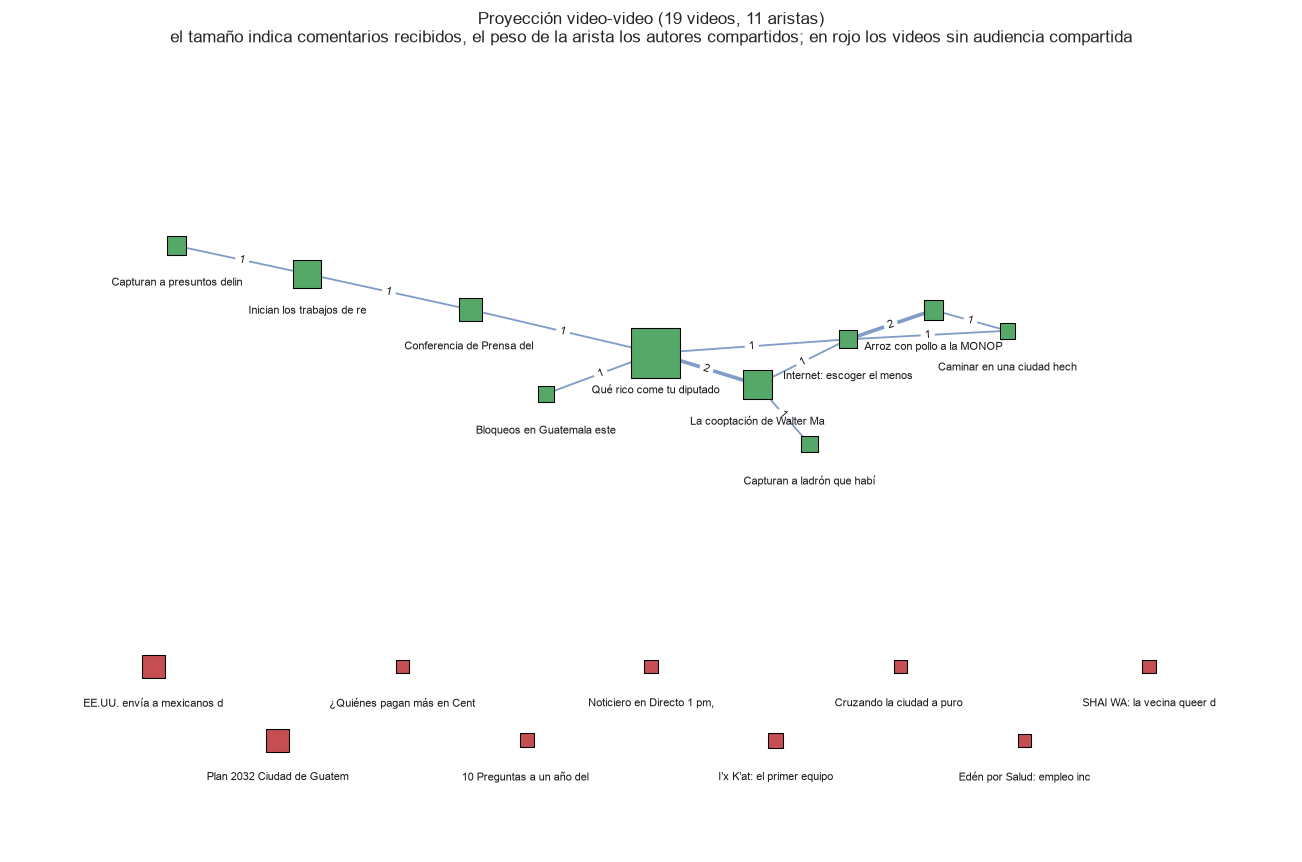

In [38]:
# colocamos la componente conectada arriba y los videos aislados en una fila abajo,
# para que ninguno quede fuera de la figura
grados_vv = dict(P_videos.degree())
conectados = [n for n in P_videos.nodes() if grados_vv[n] > 0]
aislados_vv = [n for n in P_videos.nodes() if grados_vv[n] == 0]

pos_vv = nx.spring_layout(P_videos.subgraph(conectados), k=1.1, iterations=300, seed=3)
pos_vv = {n: (x, 0.25 + 0.45 * y) for n, (x, y) in pos_vv.items()}
for i, n in enumerate(aislados_vv):
    pos_vv[n] = (-1.05 + 2.1 * i / (len(aislados_vv) - 1), -0.55 - 0.18 * (i % 2))

fig, ax = plt.subplots(figsize=(12, 8))
nx.draw_networkx_edges(P_videos, pos_vv, ax=ax, edge_color="#4C72B0", alpha=0.7,
                       width=[1.2 * d["weight"] for _, _, d in P_videos.edges(data=True)])
nx.draw_networkx_nodes(
    P_videos, pos_vv, ax=ax, node_shape="s", edgecolors="black", linewidths=0.7,
    node_size=[70 + 6 * por_video.loc[n, "comentarios"] for n in P_videos.nodes()],
    node_color=["#C44E52" if grados_vv[n] == 0 else "#55A868" for n in P_videos.nodes()])
nx.draw_networkx_labels(
    P_videos, {n: (x, y - 0.09) for n, (x, y) in pos_vv.items()},
    labels={n: titulo[n][:26] for n in P_videos.nodes()}, font_size=7, ax=ax)
etiquetas_peso = {(a, b): d["weight"] for a, b, d in P_videos.edges(data=True)}
nx.draw_networkx_edge_labels(P_videos, pos_vv, edge_labels=etiquetas_peso,
                             font_size=7, ax=ax)
ax.set_title("Proyección video-video (19 videos, 11 aristas)\n"
             "el tamaño indica comentarios recibidos, el peso de la arista los autores "
             "compartidos; en rojo los videos sin audiencia compartida")
ax.set_xlim(-1.35, 1.35)
ax.set_ylim(-1.0, 0.95)
ax.axis("off")
plt.tight_layout()
plt.show()

In [39]:
# guardamos las dos proyecciones para reutilizarlas en los ejercicios siguientes
aristas_aa = nx.to_pandas_edgelist(P_autores).rename(
    columns={"source": "autor_1", "target": "autor_2", "weight": "videos_compartidos"})
aristas_vv = nx.to_pandas_edgelist(P_videos).rename(
    columns={"source": "video_1", "target": "video_2", "weight": "autores_compartidos"})
aristas_aa.to_csv(SALIDAS / "proyeccion_autor_autor.csv", index=False)
aristas_vv.to_csv(SALIDAS / "proyeccion_video_video.csv", index=False)
print("guardadas en salidas/: proyeccion_autor_autor.csv", aristas_aa.shape,
      "| proyeccion_video_video.csv", aristas_vv.shape)

guardadas en salidas/: proyeccion_autor_autor.csv (10732, 3) | proyeccion_video_video.csv (11, 3)


Las dos figuras muestran lo mismo desde dos ángulos. En la proyección de autores se
distinguen manchas de color, y cada mancha es un video, lo que confirma que la densidad
proviene de la proyección y no de una comunidad real de usuarios que conversan entre sí.
En la proyección de videos, en cambio, se ve una cadena corta de contenidos enlazados por
uno o dos comentaristas, con los nueve videos rojos completamente desconectados. La
audiencia observada es local a cada video y el poco tránsito que existe se da sobre todo
entre videos del mismo canal.

## Ejercicio 6. Topología y fragmentación

Analizamos la estructura de las tres redes construidas, la bipartita autor-video y sus
dos proyecciones. El objetivo es describir qué tan conectada está la participación
observada, si las conexiones se reparten o se concentran, y en cuántos pedazos queda
dividida la red.

### 6.1 Nodos, aristas, densidad, grado y componentes

Reunimos las medidas básicas de las tres redes en una sola tabla para poder compararlas.
La densidad de la red bipartita se calcula contra el número de aristas posibles entre los
dos conjuntos, autores por videos, y no contra todos los pares de nodos, que es lo que
haría la fórmula general y daría un valor artificialmente bajo.

In [40]:
def resumen_red(G, nombre, densidad=None):
    grados = np.array([g for _, g in G.degree()])
    componentes = sorted(nx.connected_components(G), key=len, reverse=True)
    mayor = componentes[0]
    return pd.Series({
        "nodos": G.number_of_nodes(),
        "aristas": G.number_of_edges(),
        "densidad": round(nx.density(G) if densidad is None else densidad, 4),
        "grado medio": round(grados.mean(), 2),
        "grado mediano": float(np.median(grados)),
        "grado máximo": int(grados.max()),
        "componentes": len(componentes),
        "componente mayor": len(mayor),
        "% en la mayor": round(100 * len(mayor) / G.number_of_nodes(), 1),
        "nodos aislados": int((grados == 0).sum())}, name=nombre)

densidad_bip = B.number_of_edges() / (len(autores_ids) * len(videos_ids))
topologia = pd.concat([
    resumen_red(B, "bipartita autor-video", densidad=densidad_bip),
    resumen_red(P_autores, "proyección autor-autor"),
    resumen_red(P_videos, "proyección video-video")], axis=1)
topologia

,bipartita autor-video,proyección autor-autor,proyección video-video
nodos,351.0000,332.0000,19.0000
aristas,343.0000,10732.0000,11.0000
densidad,0.0544,0.1953,0.0643
grado medio,1.9500,64.6500,1.1600
grado mediano,1.0000,48.0000,1.0000
grado máximo,128.0000,183.0000,4.0000
componentes,10.0000,10.0000,10.0000
componente mayor,286.0000,276.0000,10.0000
% en la mayor,81.5000,83.1000,52.6000
nodos aislados,0.0000,4.0000,9.0000


red bipartita, lado de los autores:
  grado 1: 323 (97.3%) | grado 2: 7 | grado 3: 2
red bipartita, lado de los videos:
  grado mínimo: 1 | mediana: 7 | máximo: 128
  los 3 videos de mayor grado concentran 60.9% de los extremos de arista del lado de los videos


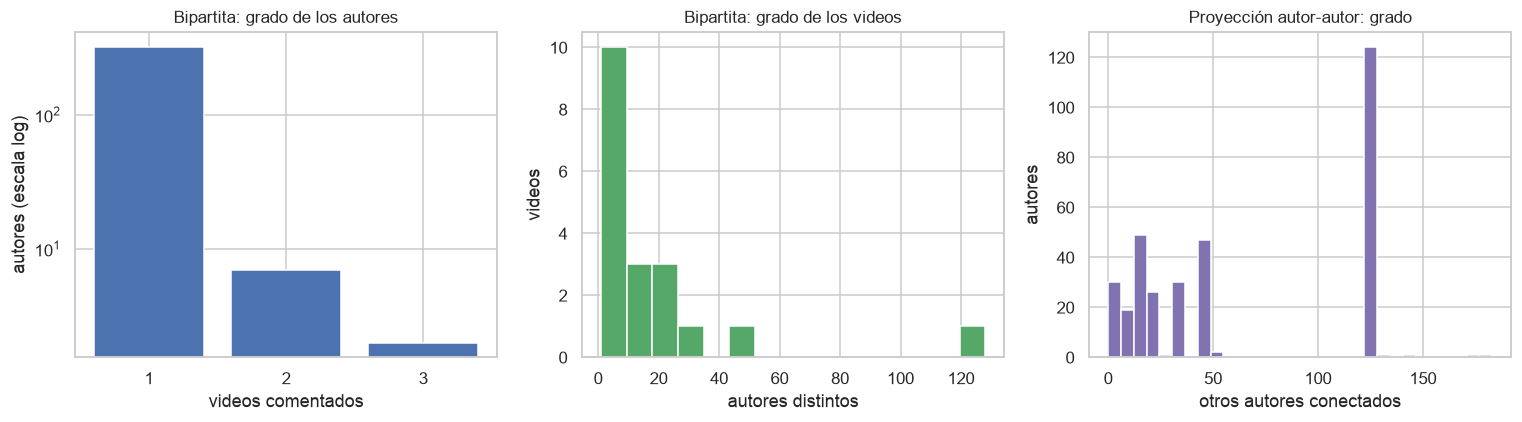

In [41]:
# distribución de grados
grados_autor = np.array([B.degree(n) for n in autores_ids])
grados_video = np.array([B.degree(n) for n in videos_ids])

print("red bipartita, lado de los autores:")
print("  grado 1:", int((grados_autor == 1).sum()),
      f"({(grados_autor == 1).mean():.1%})",
      "| grado 2:", int((grados_autor == 2).sum()),
      "| grado 3:", int((grados_autor == 3).sum()))
print("red bipartita, lado de los videos:")
print("  grado mínimo:", int(grados_video.min()), "| mediana:", int(np.median(grados_video)),
      "| máximo:", int(grados_video.max()))
print("  los 3 videos de mayor grado concentran",
      f"{np.sort(grados_video)[-3:].sum() / grados_video.sum():.1%}",
      "de los extremos de arista del lado de los videos")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(grados_autor, bins=range(1, grados_autor.max() + 2), color="#4C72B0",
             align="left", rwidth=0.8)
axes[0].set_yscale("log")
axes[0].set_title("Bipartita: grado de los autores")
axes[0].set_xlabel("videos comentados")
axes[0].set_ylabel("autores (escala log)")
axes[0].set_xticks(range(1, grados_autor.max() + 1))

axes[1].hist(grados_video, bins=15, color="#55A868")
axes[1].set_title("Bipartita: grado de los videos")
axes[1].set_xlabel("autores distintos")
axes[1].set_ylabel("videos")

grados_aa = np.array([g for _, g in P_autores.degree()])
axes[2].hist(grados_aa, bins=30, color="#8172B2")
axes[2].set_title("Proyección autor-autor: grado")
axes[2].set_xlabel("otros autores conectados")
axes[2].set_ylabel("autores")

plt.tight_layout()
plt.show()

Las tres distribuciones son muy desiguales pero por razones distintas. En la red bipartita
el grado de los autores es prácticamente constante en uno, 323 de 332 autores comentaron
en un solo video, mientras que el grado de los videos va de 1 a 128, de modo que la
desigualdad está del lado de los contenidos y no de las personas. En la proyección
autor-autor el grado no describe sociabilidad, describe el tamaño del video en el que
comentó cada quien, por eso la distribución tiene picos, un autor del video más comentado
arrastra automáticamente 127 vecinos.

### 6.2 Cohesión y transitividad

Medimos la transitividad, es decir la proporción de tríos de nodos conectados que forman
triángulos cerrados, y la cohesión de la componente más grande a través de la conectividad
de nodos y de aristas, que indican cuántos nodos o aristas habría que quitar para
desconectarla.

In [42]:
from networkx.algorithms import bipartite as bipar

print("transitividad")
print("  bipartita autor-video:", nx.transitivity(B),
      "(es cero por construcción, un grafo bipartito no puede tener triángulos)")
print("  coeficiente de agrupamiento bipartito de Latapy:",
      round(bipar.average_clustering(B), 3))
print("  proyección autor-autor:", round(nx.transitivity(P_autores), 3),
      "| agrupamiento promedio:", round(nx.average_clustering(P_autores), 3))
print("  proyección video-video:", round(nx.transitivity(P_videos), 3),
      "| agrupamiento promedio:", round(nx.average_clustering(P_videos), 3))

print("\ncohesión de la componente más grande")
for nombre, G in [("bipartita autor-video", B), ("proyección autor-autor", P_autores),
                  ("proyección video-video", P_videos)]:
    mayor = G.subgraph(max(nx.connected_components(G), key=len))
    print(f"  {nombre}: {mayor.number_of_nodes()} nodos |",
          "conectividad de nodos:", nx.node_connectivity(mayor),
          "| conectividad de aristas:", nx.edge_connectivity(mayor))

print("\npuentes de la red bipartita (aristas cuya eliminación desconecta):",
      len(list(nx.bridges(B))), "de", B.number_of_edges(), "aristas")

transitividad
  bipartita autor-video: 0 (es cero por construcción, un grafo bipartito no puede tener triángulos)
  coeficiente de agrupamiento bipartito de Latapy: 0.892


  proyección autor-autor: 0.984 | agrupamiento promedio: 0.972
  proyección video-video: 0.316 | agrupamiento promedio: 0.149

cohesión de la componente más grande


  bipartita autor-video: 286 nodos | conectividad de nodos: 1 | conectividad de aristas: 1


  proyección autor-autor: 276 nodos | conectividad de nodos: 1 | conectividad de aristas: 5
  proyección video-video: 10 nodos | conectividad de nodos: 1 | conectividad de aristas: 1

puentes de la red bipartita (aristas cuya eliminación desconecta): 335 de 343 aristas


La transitividad de la red bipartita es cero y no puede ser otra cosa, porque un triángulo
exigiría una arista entre dos autores o entre dos videos y esas aristas no existen por
definición. Por eso reportamos además el coeficiente bipartito de Latapy, que vale 0.892 y
mide el solapamiento de vecindarios, un valor alto que refleja que los autores de un mismo
video comparten exactamente el mismo vecindario.

Las transitividades altas de las proyecciones tampoco son un hallazgo sobre la audiencia.
La proyección autor-autor tiene transitividad 0.984 simplemente porque está formada por
grupos completos, y en un grupo completo todos los tríos cierran. La proyección
video-video, en cambio, tiene transitividad 0.316, que sí es interpretable, algunos videos
que comparten público con un tercero también lo comparten entre sí.

La cohesión es mínima. La conectividad de nodos de la componente más grande vale uno en
las tres redes, es decir que basta quitar un solo nodo bien elegido para partirla, y la
conectividad de aristas vale uno en la bipartita y en la video-video. La única excepción
es la conectividad de aristas de la proyección autor-autor, que vale cinco, y tampoco es
un signo de robustez real, es otra consecuencia de los grupos completos, dentro de un
video todos los autores están unidos por muchos caminos redundantes. La fragilidad se
confirma con los 335 puentes de la red bipartita, el 97.7 % de sus aristas. La red está
conectada pero no es robusta.

### 6.3 Nodos periféricos y aislados

Identificamos los nodos que quedan en la periferia y los que quedan completamente
desconectados, distinguiendo el aislamiento observado del que se debe a la falta de datos.

In [43]:
componentes_bip = sorted(nx.connected_components(B), key=len, reverse=True)
print("componentes de la red bipartita:", len(componentes_bip))
for i, comp in enumerate(componentes_bip, 1):
    vids = [n for n in comp if B.nodes[n]["tipo"] == "video"]
    print(f"  componente {i}: {len(comp)} nodos | {len(vids)} video(s):",
          ", ".join(titulo[v][:30] for v in vids))

print("\nperiferia de la red bipartita")
print("  autores de grado 1 (comentaron en un solo video):",
      int((grados_autor == 1).sum()), f"({(grados_autor == 1).mean():.1%} de los autores)")
print("  videos de grado bajo (3 autores o menos):",
      [titulo[v][:35] for v in videos_ids if B.degree(v) <= 3])

print("\nnodos aislados")
print("  en la red bipartita:", len(list(nx.isolates(B))),
      "(ningún autor ni video queda suelto, todos tienen al menos un comentario)")
print("  en la proyección autor-autor:", len(list(nx.isolates(P_autores))),
      "autores, los únicos comentaristas de su video")
print("  en la proyección video-video:", len(list(nx.isolates(P_videos))),
      "videos, sin ningún autor en común con otro video")
print("\nvideos del conjunto sin ningún comentario recolectado:",
      int((~videos["comentado"]).sum()), "de", len(videos),
      "(no aparecen en la red)")

componentes de la red bipartita: 10
  componente 1: 286 nodos | 10 video(s): Capturan a presuntos delincuen, Qué rico come tu diputado, Bloqueos en Guatemala este 31 , Capturan a ladrón que había qu, Caminar en una ciudad hecha pa, Internet: escoger el menos mal, Inician los trabajos de recupe, Conferencia de Prensa del Gobi, Arroz con pollo a la MONOPOLIO, La cooptación de Walter Mazari
  componente 2: 26 nodos | 1 video(s): Plan 2032 Ciudad de Guatemala
  componente 3: 19 nodos | 1 video(s): EE.UU. envía a mexicanos depor
  componente 4: 5 nodos | 1 video(s): I’x K’at: el primer equipo gua
  componente 5: 4 nodos | 1 video(s): 10 Preguntas a un año del Paro
  componente 6: 3 nodos | 1 video(s): Noticiero en Directo 1 pm, 28 
  componente 7: 2 nodos | 1 video(s): ¿Quiénes pagan más en Centroam
  componente 8: 2 nodos | 1 video(s): Cruzando la ciudad a puro Tran
  componente 9: 2 nodos | 1 video(s): Edén por Salud: empleo inclusi
  componente 10: 2 nodos | 1 video(s): SHAI WA: la vecin

Hay que separar dos tipos de aislamiento. El primero es observado, y corresponde a los
nueve videos que no comparten ningún comentarista con otro video y a los cuatro autores
que quedan sueltos en la proyección porque fueron los únicos en comentar su video. Ese
aislamiento sí es un resultado, dice que el público de esos contenidos no aparece en
ningún otro. El segundo es ausencia de datos, y afecta a los 274 videos que no tienen
comentarios recolectados y que por lo tanto ni siquiera entran a la red. De esos videos no
podemos afirmar que estén aislados, simplemente no fueron observados, y lo mismo ocurre
con las respuestas a los comentarios, que existen pero no se recolectaron con su autor y
podrían cambiar la estructura si estuvieran disponibles.

### 6.4 Hallazgos estructurales

La estructura que muestran las métricas y las figuras es la de una red de estrellas
débilmente encadenadas. Cada video funciona como un centro rodeado de comentaristas que no
aparecen en ningún otro contenido, y la red completa se mantiene unida solamente por nueve
autores. La componente más grande abarca el 81.5 % de los nodos, lo que a primera vista
sugiere una red integrada, pero la conectividad de nodos igual a uno y los 335 puentes
muestran que esa integración es frágil, sostenida por aristas únicas que no tienen
respaldo alternativo.

El grado medio de 1.95 en la red bipartita, con mediana 1, confirma que la participación
típica es una sola intervención en un solo video. La desigualdad estructural está del lado
de los contenidos, no de las personas, un video reúne 128 comentaristas distintos y cuatro
videos reúnen uno solo. Esto es coherente con lo que se vio en el análisis exploratorio, la
concentración se da en los videos y en los canales, mientras que los autores están muy
repartidos.

Las dos proyecciones confirman lo mismo desde ángulos opuestos. La autor-autor es densa
pero esa densidad es un artefacto de proyectar grupos completos, y su transitividad de
0.984 no describe cohesión social. La video-video es escasa, con 11 aristas y 9 videos
aislados, y es la que revela el fenómeno de fondo, en la participación observada casi no
hay tránsito de público entre contenidos, y el poco que hay ocurre sobre todo dentro del
mismo canal. En términos de fragmentación, la conversación observada no es un espacio
público compartido sino un conjunto de audiencias paralelas que apenas se tocan.

## Ejercicio 7. Comunidades

Sección a cargo de Fernando Rueda. Se desarrolla sobre las proyecciones construidas en el
ejercicio 5 y va antes del ejercicio 8 en la versión final del documento.

In [50]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from networkx.algorithms import bipartite as bip, community as nxcom

SEMILLA = 23748
ROOT = Path.cwd()
while not (ROOT / ".git").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
SALIDAS = ROOT / "salidas"

com = pd.read_csv(SALIDAS / "comentarios_procesado.csv")
com["author_channel_id"] = com["author_channel_id"].astype(str)
com["video_id"] = com["video_id"].astype(str)

# traemos la categoría del video (solo está en el conjunto de videos)
vids = pd.read_csv(SALIDAS / "videos_procesado.csv")[["video_id", "category"]]
vids["video_id"] = vids["video_id"].astype(str)
com = com.merge(vids, on="video_id", how="left")

# reconstruimos la red bipartita autor-video y la proyección autor-autor del ej. 5
peso_av = com.groupby(["author_channel_id", "video_id"]).size().reset_index(name="n")
B = nx.Graph()
B.add_nodes_from(peso_av["author_channel_id"].unique(), bipartite="autor")
B.add_nodes_from(peso_av["video_id"].unique(), bipartite="video")
B.add_weighted_edges_from(peso_av.itertuples(index=False, name=None))
autores_ids = set(peso_av["author_channel_id"])
P_autores = bip.weighted_projected_graph(B, autores_ids)
print("proyección autor-autor:", P_autores.number_of_nodes(), "autores,",
      P_autores.number_of_edges(), "aristas")

proyección autor-autor: 332 autores, 10732 aristas


### 7.1 Red elegida para detectar comunidades

Detectamos comunidades sobre la proyección autor-autor construida en el ejercicio 5,
donde dos autores se conectan si comentaron en el mismo video y el peso es el número
de videos que comparten. Es la red adecuada porque agrupa a las personas por su
coasistencia a las mismas secciones de comentarios, que es la forma de participación
que sí observamos en los datos. No usamos la red bipartita directamente porque los
algoritmos de comunidades estándar están pensados para redes de un solo tipo de nodo,
y no usamos la proyección video-video porque tiene muy pocas aristas.

### 7.2 Algoritmo, supuestos y tratamiento de los pesos

Aplicamos el algoritmo de Louvain, que busca una partición que maximice la
modularidad, es decir, que deje muchas más aristas dentro de los grupos que las
esperadas al azar. Louvain es apropiado aquí porque es eficiente, no necesita fijar
de antemano el número de comunidades y aprovecha los pesos de las aristas, que en
nuestra proyección indican cuántos videos comparten dos autores. Usamos los pesos en
el cálculo y fijamos una semilla para que el resultado sea reproducible. El supuesto
principal es que una comunidad corresponde a un grupo de autores más conectados entre
sí que con el resto, que en este caso equivale a haber coincidido en los mismos
videos.

In [51]:
comunidades = nxcom.louvain_communities(P_autores, weight="weight", seed=SEMILLA)
comunidades = sorted(comunidades, key=len, reverse=True)
modularidad = nxcom.modularity(P_autores, comunidades, weight="weight")

com_de_autor = {}
for k, grupo in enumerate(comunidades):
    for autor in grupo:
        com_de_autor[autor] = k
com["comunidad"] = com["author_channel_id"].map(com_de_autor)

print("número de comunidades:", len(comunidades))
print("modularidad:", round(modularidad, 3))
print("tamaños de las comunidades:", [len(c) for c in comunidades])

número de comunidades: 14
modularidad: 0.395
tamaños de las comunidades: [126, 61, 55, 28, 25, 18, 6, 4, 3, 2, 1, 1, 1, 1]


### 7.3 Número de comunidades, tamaños y calidad

El algoritmo encuentra varias comunidades con una modularidad alta, lo que indica una
estructura de grupos muy marcada. Eso era esperable, porque al proyectar la red los
comentaristas de un mismo video forman un grupo completamente conectado entre sí, así
que cada video tiende a producir su propia comunidad y las comunidades solo se unen
cuando algunos autores comentaron en más de un video.

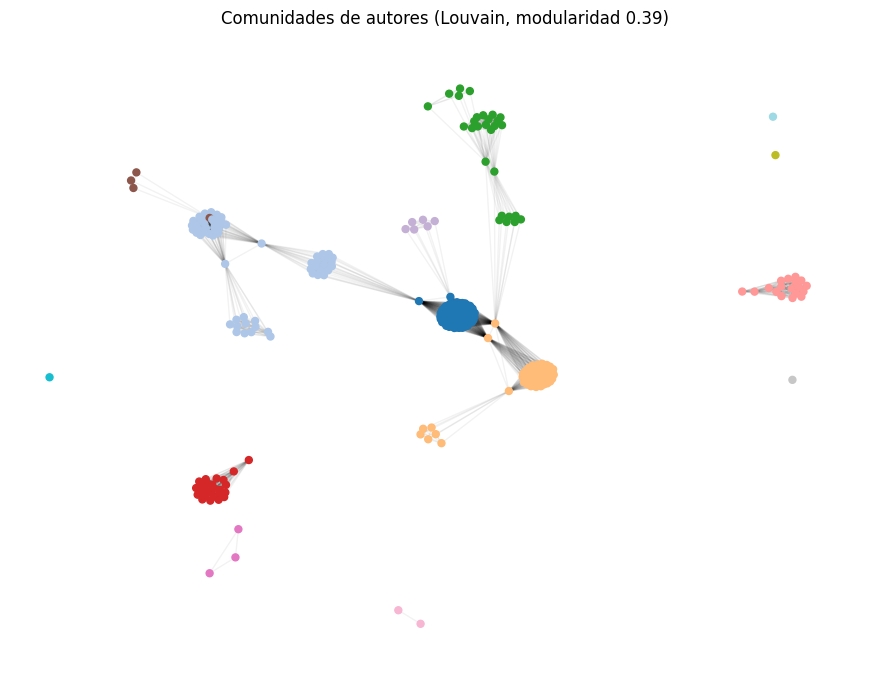

In [52]:
fig, ax = plt.subplots(figsize=(9, 7))
pos = nx.spring_layout(P_autores, seed=SEMILLA, k=0.15)
colores = [com_de_autor[n] for n in P_autores.nodes()]
nx.draw_networkx_edges(P_autores, pos, alpha=0.05, ax=ax)
nx.draw_networkx_nodes(P_autores, pos, node_color=colores, cmap="tab20",
                       node_size=25, ax=ax)
ax.set_title(f"Comunidades de autores (Louvain, modularidad {modularidad:.2f})")
ax.axis("off")
plt.tight_layout()
plt.show()

### 7.5 Caracterización de las comunidades principales

Describimos las tres comunidades más grandes por el video y el canal en que se
concentran, el número de autores y de comentarios, y las palabras más frecuentes. La
caracterización por sentimiento se retoma en el ejercicio 9, donde comparamos el
sentimiento por comunidad con la herramienta adecuada.

In [53]:
from collections import Counter

def palabras_top(textos, k=8):
    palabras = []
    for t in textos.fillna(""):
        palabras.extend(str(t).split())
    return [w for w, _ in Counter(palabras).most_common(k)]

for k in range(min(3, len(comunidades))):
    sub = com[com["comunidad"] == k]
    video = sub["video_title"].mode().iloc[0] if "video_title" in sub else sub["video_id"].mode().iloc[0]
    canal = sub["channel_name"].mode().iloc[0] if sub["channel_name"].notna().any() else "s/d"
    print(f"== comunidad {k} ==")
    print(f"  autores: {sub['author_channel_id'].nunique()} | comentarios: {len(sub)}")
    print(f"  video principal: {str(video)[:70]}")
    print(f"  canal: {canal}")
    print(f"  palabras frecuentes: {palabras_top(sub['texto_limpio'])}")
    print()

== comunidad 0 ==
  autores: 126 | comentarios: 161
  video principal: Qué rico come tu diputado
  canal: Quorum
  palabras frecuentes: ['ser', 'pueblo', 'diputado', 'tener', 'pagar', 'hacer', 'dinero', 'trabajo']

== comunidad 1 ==
  autores: 61 | comentarios: 83
  video principal: Inician los trabajos de recuperación del Puente Belice II.
  canal: Gobierno de la República de Guatemala
  palabras frecuentes: ['ser', 'presidente', 'haber', 'hacer', 'guatemala', 'país', 'año', 'tener']

== comunidad 2 ==
  autores: 55 | comentarios: 60
  video principal: La cooptación de Walter Mazariegos en la USAC
  canal: Quorum
  palabras frecuentes: ['ser', 'corrupto', 'haber', 'usac', 'tener', 'poder', 'estudiante', 'universidad']



Las comunidades principales coinciden con los videos que concentraron más
comentarios, y cada una reúne a las personas que participaron en la sección de ese
video. Esto confirma que la participación observada se organiza alrededor de videos
concretos y no de audiencias que sigan a varios videos a la vez, un hallazgo que hay
que leer con cuidado porque es consecuencia de cómo se recolectaron los datos.

## Ejercicio 8. Nodos centrales y participantes puente

Calculamos las medidas de centralidad sobre la red bipartita autor-video, y no sobre las
proyecciones, porque la proyección autor-autor convierte cada video en un grupo completo y
eso inflaría artificialmente el grado y el agrupamiento de cualquier autor que haya
comentado en un video popular. Sobre la red bipartita las medidas conservan su
interpretación original, un camino entre dos autores siempre pasa por los videos que los
conectan.

### 8.1 Medidas de centralidad

Usamos cuatro medidas complementarias. El **grado** cuenta las conexiones directas, para un
autor son los videos en los que comentó y para un video los autores distintos que
participaron; junto a él reportamos la **fuerza**, que es el grado ponderado por el número
de comentarios. La **intermediación** mide cuántos caminos más cortos pasan por un nodo y
es la medida clave en una red fragmentada como esta, porque identifica a los nodos que
conectan partes que de otra forma quedarían separadas. La **cercanía** mide qué tan cerca
está un nodo del resto de su componente y sirve para ver quién ocupa el centro de la
estructura. Añadimos **PageRank** ponderado, que reparte importancia siguiendo las aristas
y toma en cuenta el peso, es decir la insistencia de un autor en un mismo video, y la
**centralidad de vector propio**, que premia estar conectado a nodos que a su vez están
bien conectados. Todas se calculan sobre la red completa, de modo que los nodos de
componentes pequeñas obtienen valores bajos por construcción.

In [44]:
centralidad = pd.DataFrame({
    "grado": dict(B.degree()),
    "fuerza": dict(B.degree(weight="peso")),
    "intermediacion": nx.betweenness_centrality(B),
    "cercania": nx.closeness_centrality(B),
    "pagerank": nx.pagerank(B, weight="peso"),
    "vector_propio": nx.eigenvector_centrality(B, max_iter=1000)})
centralidad["tipo"] = pd.Series(nx.get_node_attributes(B, "tipo"))
centralidad["etiqueta"] = centralidad.index.map(
    lambda n: titulo[n] if n in titulo else etiqueta_autor.get(n, n))
centralidad = centralidad[["tipo", "etiqueta", "grado", "fuerza", "intermediacion",
                           "cercania", "pagerank", "vector_propio"]]
centralidad.to_csv(SALIDAS / "centralidad.csv")

print("correlación de rangos entre medidas (red completa):")
print(centralidad[["grado", "intermediacion", "cercania", "pagerank",
                   "vector_propio"]].corr(method="spearman").round(2).to_string())

correlación de rangos entre medidas (red completa):
                grado  intermediacion  cercania  pagerank  vector_propio
grado            1.00            1.00      0.01      0.43          -0.00
intermediacion   1.00            1.00      0.02      0.43           0.01
cercania         0.01            0.02      1.00     -0.22           0.99
pagerank         0.43            0.43     -0.22      1.00          -0.19
vector_propio   -0.00            0.01      0.99     -0.19           1.00


La matriz de correlación de rangos ya adelanta la estructura de la red. El grado y la
intermediación correlacionan en 1.00, algo poco habitual, y ocurre porque casi todos los
nodos empatan en los valores más bajos, 323 autores tienen grado 1 e intermediación 0, de
modo que el orden lo definen los pocos nodos que sobresalen. La cercanía y la centralidad
de vector propio correlacionan en 0.99 entre sí pero casi en cero con el grado, lo que
indica que estar cerca del centro de la red y tener muchas conexiones son cosas distintas
aquí. El PageRank se despega de todas las demás porque incorpora los pesos, es decir el
número de comentarios, y no solo la topología.

### 8.2 Interpretación por tipo de nodo

Los dos conjuntos de nodos no son comparables entre sí, un video con 128 comentaristas
tendrá siempre más grado que cualquier autor, así que interpretamos cada lado por separado.

In [45]:
autores_c = centralidad[centralidad["tipo"] == "autor"]
print("AUTORES: los 10 de mayor intermediación")
print(autores_c.nlargest(10, "intermediacion")[
    ["etiqueta", "grado", "fuerza", "intermediacion", "cercania"]].round(4).to_string(index=False))
print("\nAUTORES: los 5 de mayor PageRank (pesa la insistencia en un mismo video)")
print(autores_c.nlargest(5, "pagerank")[
    ["etiqueta", "grado", "fuerza", "pagerank", "intermediacion"]].round(4).to_string(index=False))

AUTORES: los 10 de mayor intermediación
             etiqueta  grado  fuerza  intermediacion  cercania
 /@virgiliogarcia3039      2       3          0.2316    0.2528
      /@inge_vergueta      3       3          0.2181    0.2655
        /@josegil3813      2       2          0.1768    0.1827
        /@Jel.Awesh.M      2       3          0.0892    0.2479
       /@hashojea7348      3       4          0.0597    0.1732
/@franciscoflores3120      2       2          0.0579    0.1346
     /@Alejandro00710      2       2          0.0323    0.1717
  /@MarcosCarillo-b1r      2       2          0.0319    0.1761
   /@moisesvaldez4043      2       2          0.0319    0.2249
   /@JorgeMunoz-gd9et      1       1          0.0000    0.1326

AUTORES: los 5 de mayor PageRank (pesa la insistencia en un mismo video)
               etiqueta  grado  fuerza  pagerank  intermediacion
    /@eugeneramirez4405      1       6    0.0055          0.0000
    /@Murmullodelbarrio      1       6    0.0053          0.000

In [46]:
videos_c = centralidad[centralidad["tipo"] == "video"]
print("VIDEOS: ordenados por intermediación")
print(videos_c.nlargest(10, "intermediacion")[
    ["etiqueta", "grado", "fuerza", "intermediacion", "cercania", "vector_propio"]]
    .round(4).to_string(index=False))

VIDEOS: ordenados por intermediación
                                                                                  etiqueta  grado  fuerza  intermediacion  cercania  vector_propio
                                                                 Qué rico come tu diputado    128     161          0.5657    0.3046         0.7068
                               Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt     19      25          0.2440    0.2157         0.0065
                                             La cooptación de Walter Mazariegos en la USAC     49      50          0.2275    0.2214         0.0180
                                Inician los trabajos de recuperación del Puente Belice II.     32      45          0.1876    0.1583         0.0001
                                                           Internet: escoger el menos malo     10      12          0.1283    0.2114         0.0061
                                                            Arroz con pollo a la 

**Autores.** Del lado de los autores la centralidad se explica por dos comportamientos
distintos. La intermediación premia la **diversidad** de participación, y la encabezan
virgiliogarcia3039 con 0.232 e inge_vergueta con 0.218, que con apenas dos y tres
comentarios enlazan videos de canales diferentes. Los nueve autores con intermediación
mayor que cero son exactamente los nueve que comentaron en más de un video, todos los demás
valen cero, lo que confirma que en esta red no hay caminos alternativos. El PageRank, en
cambio, premia la **recurrencia**, y lo encabezan autores de grado uno como
eugeneramirez4405 y Murmullodelbarrio, que comentaron cinco o seis veces en un solo video;
son participantes intensos pero no conectan nada. Los dos perfiles no coinciden y conviene
no confundirlos, el autor que insiste en un contenido no es el que integra la red.

**Videos.** Del lado de los videos la centralidad mide alcance y capacidad de conectar
audiencias. *Qué rico come tu diputado* domina en las cuatro medidas, con grado 128,
intermediación 0.566 y centralidad de vector propio 0.707, es decir que además de reunir
la mayor audiencia es el nodo por el que pasa la mayoría de los caminos de la red. El
segundo lugar en intermediación es revelador, la *Conferencia de Prensa del Gobierno*
tiene apenas 19 comentaristas pero alcanza 0.244, más que *La cooptación de Walter
Mazariegos*, que tiene 49; su posición importa no por tamaño sino por ubicación, es el
video que enlaza el bloque de contenidos de gobierno con el de Quorum. La cercanía ordena
de forma parecida y la centralidad de vector propio, en cambio, se concentra casi por
completo en el video más comentado y en sus vecinos inmediatos, lo que la vuelve poco
informativa en una red tan fragmentada.

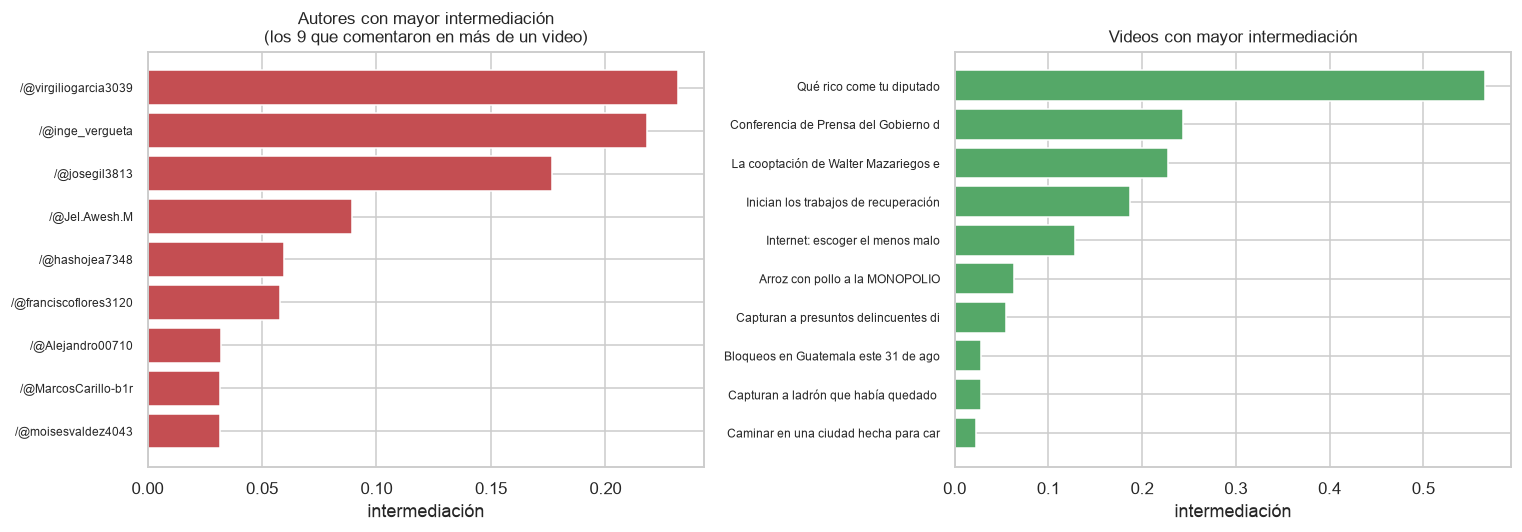

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_aut = autores_c.nlargest(9, "intermediacion").iloc[::-1]
axes[0].barh(top_aut["etiqueta"], top_aut["intermediacion"], color="#C44E52")
axes[0].set_title("Autores con mayor intermediación\n(los 9 que comentaron en más de un video)")
axes[0].set_xlabel("intermediación")
axes[0].tick_params(axis="y", labelsize=8)

top_vid = videos_c.nlargest(10, "intermediacion").iloc[::-1]
axes[1].barh([t[:36] for t in top_vid["etiqueta"]], top_vid["intermediacion"],
             color="#55A868")
axes[1].set_title("Videos con mayor intermediación")
axes[1].set_xlabel("intermediación")
axes[1].tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()

### 8.3 Participantes recurrentes, autores puente y videos articuladores

Un nodo de articulación es aquel cuya eliminación aumenta el número de componentes de la
red. Los identificamos y medimos cuánto se fragmenta la red si se eliminan.

In [48]:
articuladores = set(nx.articulation_points(B))
art_videos = [n for n in articuladores if B.nodes[n]["tipo"] == "video"]
art_autores = [n for n in articuladores if B.nodes[n]["tipo"] == "autor"]

print("nodos de articulación:", len(articuladores),
      f"({len(art_videos)} videos y {len(art_autores)} autores)")

print("\nautores puente (su eliminación desconecta la red):")
print(autores_c.loc[art_autores].sort_values("intermediacion", ascending=False)[
    ["etiqueta", "grado", "fuerza", "intermediacion"]].round(4).to_string(index=False))

print("\nparticipantes recurrentes (más comentarios publicados):")
print(autores_c.nlargest(8, "fuerza")[["etiqueta", "grado", "fuerza", "intermediacion"]]
      .to_string(index=False))

nodos de articulación: 22 (15 videos y 7 autores)

autores puente (su eliminación desconecta la red):
             etiqueta  grado  fuerza  intermediacion
 /@virgiliogarcia3039      2       3          0.2316
      /@inge_vergueta      3       3          0.2181
        /@josegil3813      2       2          0.1768
       /@hashojea7348      3       4          0.0597
/@franciscoflores3120      2       2          0.0579
   /@moisesvaldez4043      2       2          0.0319
  /@MarcosCarillo-b1r      2       2          0.0319

participantes recurrentes (más comentarios publicados):
                        etiqueta  grado  fuerza  intermediacion
             /@eugeneramirez4405      1       6        0.000000
             /@Murmullodelbarrio      1       6        0.000000
                   /@ManuelEdran      1       5        0.000000
         /@albertoshernandez5251      1       5        0.000000
/@ErvinLeonardoCarreraLat%C3%ADn      1       4        0.000000
                  /@hashojea7348 

In [49]:
def fragmentacion(G, quitar):
    H = G.copy()
    H.remove_nodes_from(quitar)
    comps = sorted(nx.connected_components(H), key=len, reverse=True)
    return len(comps), len(comps[0])

base_comp, base_mayor = nx.number_connected_components(B), len(max(nx.connected_components(B), key=len))
print(f"red completa: {base_comp} componentes, la mayor con {base_mayor} nodos")

n_comp, mayor = fragmentacion(B, art_autores)
print(f"sin los {len(art_autores)} autores puente: {n_comp} componentes, "
      f"la mayor con {mayor} nodos")

print("\nefecto de quitar cada video articulador, uno por uno:")
efecto = []
for v in art_videos:
    n_comp, mayor = fragmentacion(B, [v])
    efecto.append((titulo[v][:45], B.degree(v), n_comp - base_comp, mayor))
efecto = pd.DataFrame(efecto, columns=["video", "grado", "componentes_extra", "mayor_resultante"])
print(efecto.sort_values(["componentes_extra", "grado"], ascending=False).to_string(index=False))

red completa: 10 componentes, la mayor con 286 nodos
sin los 7 autores puente: 17 componentes, la mayor con 173 nodos

efecto de quitar cada video articulador, uno por uno:
                                        video  grado  componentes_extra  mayor_resultante
                    Qué rico come tu diputado    128                126                88
La cooptación de Walter Mazariegos en la USAC     49                 47               231
Inician los trabajos de recuperación del Puen     32                 31               241
                Plan 2032 Ciudad de Guatemala     25                 24               286
Conferencia de Prensa del Gobierno de Guatema     19                 18               222
EE.UU. envía a mexicanos deportados a Guatema     18                 17               286
               Arroz con pollo a la MONOPOLIO     16                 14               271
Capturan a presuntos delincuentes disfrazados     13                 12               273
              Int

Los resultados separan con claridad dos papeles que suelen confundirse. Los **participantes
recurrentes** son los autores con más comentarios, como eugeneramirez4405 y
Murmullodelbarrio con seis cada uno, pero todos tienen grado uno e intermediación cero,
así que su insistencia no aporta nada a la conectividad de la red. Los **autores puente**
son otros siete, que publicaron entre dos y cuatro comentarios en total, y son los que sostienen la componente
grande, al eliminarlos la red pasa de 10 a 17 componentes y la mayor se reduce de 286 a
173 nodos, es decir que siete personas con un par de comentarios cada una explican casi la mitad
de la integración observada.

Los **videos articuladores** son 15 de los 19, lo cual es esperable en una estructura de
estrellas, casi cualquier video separa a sus propios comentaristas del resto. Los
interesantes son los que más reducen la componente grande al eliminarlos, *Qué rico come tu diputado*,
*La cooptación de Walter Mazariegos*, *Internet: escoger el menos malo*, la *Conferencia
de Prensa del Gobierno* y *Inician los trabajos de recuperación del Puente Belice II*, que
funcionan como articulaciones de la cadena que une los bloques de contenido.

La conclusión estructural es que la red no tiene un núcleo robusto de participantes
influyentes. Su cohesión depende de un puñado de personas que comentaron dos veces por
casualidad y de unos pocos videos que actúan como puntos de paso obligados. Como toda
esta lectura se basa en los comentarios efectivamente recolectados, un muestreo más amplio
podría revelar puentes adicionales, y por eso conviene leer estos nombres como los puentes
observados y no como los puentes reales de la audiencia.

## Ejercicio 9. Análisis de contenido y sentimiento

Analizamos el sentimiento de los comentarios y lo comparamos entre videos y
comunidades para entender el tono de la participación.

### 9.1 Herramienta de sentimiento para español

Los comentarios están en español, así que usamos pysentimiento, un modelo basado en
RoBERTuito, una versión de RoBERTa entrenada con millones de tuits en español. Lo
elegimos sobre los léxicos tradicionales porque está entrenado con lenguaje de redes
sociales, entiende la negación y el contexto, y devuelve una de tres clases,
positivo, negativo o neutro, con su probabilidad. Aplicamos el modelo sobre el texto
original y no sobre el limpio, porque aprovecha los acentos, los signos y las
mayúsculas para medir la intensidad.

In [54]:
from pysentimiento import create_analyzer

analizador = create_analyzer(task="sentiment", lang="es")
textos = com["texto_original"].fillna("").astype(str).tolist()
predicciones = analizador.predict(textos)
com["sentimiento"] = [p.output for p in predicciones]
com["sent_neg"] = [round(p.probas["NEG"], 4) for p in predicciones]
com["sent_pos"] = [round(p.probas["POS"], 4) for p in predicciones]

etiqueta = {"POS": "positivo", "NEG": "negativo", "NEU": "neutro"}
com["sentimiento"] = com["sentimiento"].map(etiqueta)
print("distribución de sentimiento de los comentarios:")
print(com["sentimiento"].value_counts())

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Map:   0%|          | 0/406 [00:00<?, ? examples/s]

/Users/fernandor/Documents/UVG/4to_año/8vo semestre/Data Science/Lab6_DS/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


distribución de sentimiento de los comentarios:
sentimiento
negativo    249
neutro       79
positivo     78
Name: count, dtype: int64


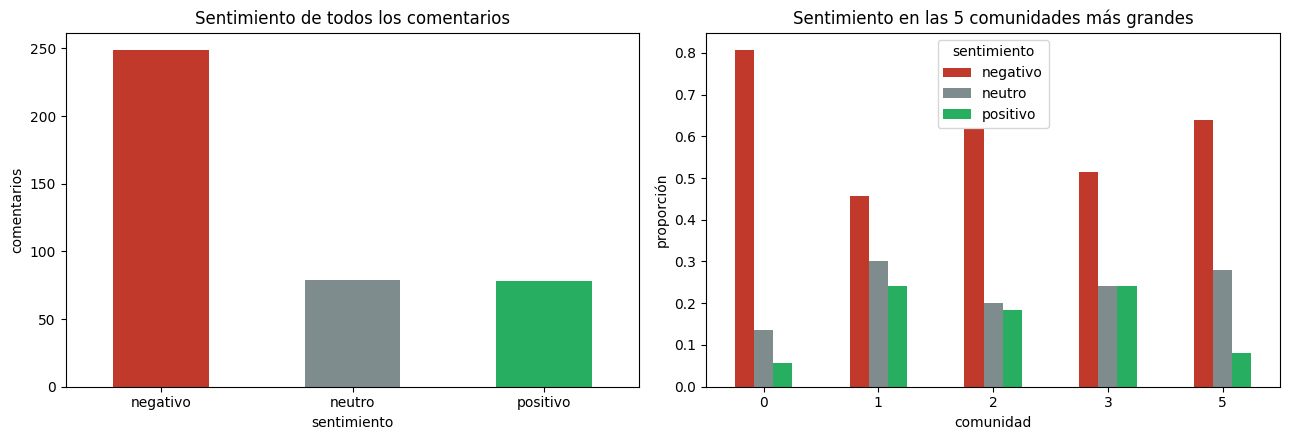

In [55]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 4.5))
orden = ["negativo", "neutro", "positivo"]
col = {"negativo": "#c0392b", "neutro": "#7f8c8d", "positivo": "#27ae60"}
com["sentimiento"].value_counts().reindex(orden).plot.bar(
    ax=ejes[0], color=[col[o] for o in orden])
ejes[0].set_title("Sentimiento de todos los comentarios")
ejes[0].set_ylabel("comentarios")
ejes[0].tick_params(axis="x", rotation=0)

top_com = com["comunidad"].value_counts().head(5).index
tabla = (com[com["comunidad"].isin(top_com)]
         .groupby("comunidad")["sentimiento"].value_counts(normalize=True)
         .unstack().reindex(columns=orden).loc[top_com])
tabla.plot.bar(ax=ejes[1], color=[col[o] for o in orden])
ejes[1].set_title("Sentimiento en las 5 comunidades más grandes")
ejes[1].set_ylabel("proporción")
ejes[1].tick_params(axis="x", rotation=0)
ejes[1].legend(title="sentimiento")
plt.tight_layout()
plt.show()

### 9.2 y 9.3 Comparación y hallazgos

La mayoría de los comentarios tienen carga negativa, algo esperable en un conjunto
dominado por videos de noticias y política. Al comparar por comunidad, que en la
práctica equivale a comparar por video, se ve que el tono no es uniforme, hay
secciones de comentarios claramente más negativas que otras según el tema del video.
Los videos de noticias y política concentran la participación más negativa, mientras
que las comunidades ligadas a otros temas muestran una mezcla más equilibrada. Esta
comparación solo es confiable en las comunidades con suficientes comentarios, así que
la limitamos a las más grandes.

In [56]:
resumen_sent = (com.groupby("category")["sent_neg"].agg(["mean", "count"])
                .rename(columns={"mean": "negatividad_media", "count": "comentarios"})
                .sort_values("negatividad_media", ascending=False).round(3))
print("negatividad media por categoría del video:")
print(resumen_sent[resumen_sent["comentarios"] >= 10])
com.to_csv(SALIDAS / "comentarios_sentimiento.csv", index=False)

negatividad media por categoría del video:
                 negatividad_media  comentarios
category                                       
News & Politics              0.602          335
Entertainment                0.473           70


## Ejercicio 10. Interpretación, limitaciones y conclusiones

### 10.1 Los hallazgos en su contexto

El análisis describe cómo se organizó la participación observada en un conjunto de
videos de YouTube, en su mayoría de noticias y política de Guatemala. La
participación está muy concentrada, los comentarios se reparten en unos pocos videos
y la red de coasistencia entre autores se organiza en comunidades que coinciden con
esos videos. El contenido de los comentarios es mayoritariamente negativo, y ese tono
varía según el tema del video. En conjunto, lo que vemos es un público que reacciona
video por video más que una audiencia que circule entre varios videos.

### 10.2 Limitaciones

Los resultados están condicionados por cómo se recolectaron los datos y no deben
leerse como una imagen completa de YouTube. La cobertura de comentarios es parcial,
solo hay 406 comentarios principales repartidos en unos pocos videos, así que las
comunidades reflejan esa muestra y no toda la conversación. La selección de videos
depende de las consultas de búsqueda usadas, lo que sesga los temas hacia noticias y
política. Las fechas son relativas y los conteos de visualizaciones y de me gusta se
observaron en el momento de la recolección, así que cambian con el tiempo. No existe
información de quién respondió a quién, por lo que la red no representa conversaciones
ni relaciones entre usuarios, solo coasistencia a las mismas secciones de
comentarios. Finalmente, la fuerte concentración de comentarios en pocos videos hace
que unas pocas secciones dominen todo el análisis.

### 10.3 Descripción, asociación e inferencia

Conviene distinguir tres niveles. Lo que reportamos es descripción, cómo luce la
participación en esta muestra concreta. Algunas relaciones, como que los videos de
noticias concentran comentarios más negativos, son asociaciones observadas en estos
datos, no relaciones causales. Y no hacemos inferencia hacia toda la población de
YouTube ni hacia toda Guatemala, porque la muestra no es representativa. Una comunidad
en esta red significa haber comentado en los mismos videos, y una arista significa
coasistencia, nunca amistad, conversación ni acuerdo.

### 10.4 Conclusiones

Uniendo redes, contenido y sentimiento, el retrato que surge es coherente. La
estructura de la red muestra una participación fragmentada, organizada en comunidades
que son en realidad las secciones de comentarios de videos concretos, con muy poca
audiencia compartida entre ellos. El contenido y el sentimiento muestran un tono
predominantemente negativo, más marcado en los videos de noticias y política, que son
los que más participación concentran. Las medidas de centralidad y las comunidades
apuntan al mismo punto, la conversación observada gira alrededor de unos pocos videos
muy comentados. Todo esto describe la muestra recolectada y, por las limitaciones
señaladas, no debe generalizarse, pero sí ofrece un método reproducible para estudiar
la participación en YouTube que podría aplicarse a una recolección más amplia y
balanceada.